<a href="https://colab.research.google.com/github/Aminah-creat/BUSINESS_INTELLIGENCE_ASSIGNMENT1_UWIMANA_Amina_223009215/blob/main/BI_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving BI_Retail_Case_Study.xlsx to BI_Retail_Case_Study.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(FILE, sheet_name="SalesRaw")
products = pd.read_excel(FILE, sheet_name="DimProduct")
customers = pd.read_excel(FILE, sheet_name="DimCustomer")
stores = pd.read_excel(FILE, sheet_name="DimStore")
employees = pd.read_excel(FILE, sheet_name="DimEmployee")
dates = pd.read_excel(FILE, sheet_name="DimDate")
targets = pd.read_excel(FILE, sheet_name="Targets")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
print("Sales:", sales.shape)
print("Products:", products.shape)
print("Customers:", customers.shape)
print("Stores:", stores.shape)
print("Employees:", employees.shape)
print("Dates:", dates.shape)
print("Targets:", targets.shape)

Sales: (25035, 14)
Products: (60, 5)
Customers: (5000, 6)
Stores: (8, 5)
Employees: (40, 4)
Dates: (365, 8)
Targets: (96, 3)


## Question 1: Does High Revenue Mean High Profit?

What I Expect to Find:

Management assumes that products with the highest Net Sales also generate the highest Gross Profit. I expect that this may not always be true because products can have different unit costs and therefore different profit margins. I will calculate product-level sales, quantity, cost, gross profit and profit margin, and then compare the sales ranking with the profit ranking.

In [ ]:
# Load the 'DimProduct' sheet from the Excel file
df_dim_product = pd.read_excel('BI_Retail_Case_Study.xlsx', sheet_name='DimProduct')

print('DimProduct DataFrame Info:')
df_dim_product.info()

print('\nFirst 5 rows of DimProduct DataFrame:')
display(df_dim_product.head())

# Merge the sales data (df) with the product dimension data (df_dim_product)
# This will bring in ProductName, Category, and UnitCost for each transaction
df_merged = pd.merge(df, df_dim_product, on='ProductID', how='left')

print('\nMerged DataFrame Info:')
df_merged.info()

print('\nFirst 5 rows of Merged DataFrame:')
display(df_merged.head())

DimProduct DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ProductID          60 non-null     int64 
 1   ProductName        60 non-null     object
 2   Category           60 non-null     object
 3   StandardUnitPrice  60 non-null     int64 
 4   UnitCost           60 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 2.5+ KB

First 5 rows of DimProduct DataFrame:


,ProductID,ProductName,Category,StandardUnitPrice,UnitCost
0,1,Rice 5kg,Food & Beverage,6500,4800
1,2,Cooking Oil 1L,Food & Beverage,3200,2400
2,3,Milk 1L,Food & Beverage,1800,1300
3,4,Sugar 1kg,Food & Beverage,1700,1250
4,5,Biscuits Pack,Food & Beverage,1200,800



Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25035 entries, 0 to 25034
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      25035 non-null  object        
 1   TransactionDate    25035 non-null  datetime64[ns]
 2   StoreID            25035 non-null  int64         
 3   EmployeeID         25035 non-null  int64         
 4   CustomerID         25035 non-null  int64         
 5   ProductID          25035 non-null  int64         
 6   Quantity           25035 non-null  int64         
 7   UnitPrice          24985 non-null  float64       
 8   DiscountPct        24975 non-null  float64       
 9   SalesChannel       25035 non-null  object        
 10  PaymentMethod      25035 non-null  object        
 11  GrossSales         25035 non-null  int64         
 12  DiscountAmount     25035 non-null  float64       
 13  NetSales           25035 non-null  fl

,TransactionID,TransactionDate,StoreID,EmployeeID,CustomerID,ProductID,Quantity,UnitPrice,DiscountPct,SalesChannel,PaymentMethod,GrossSales,DiscountAmount,NetSales,ProductName,Category,StandardUnitPrice,UnitCost
0,TX100000,2025-06-29,3,2016,10538,10,2,2660.0,0.10,Store,Mobile Money,5320,532.0,4788.0,Flour 2kg,Food & Beverage,2600,1900
1,TX100001,2025-12-31,6,2028,10107,26,6,25204.0,0.05,Store,Mobile Money,151224,7561.2,143662.8,Table Lamp,Home & Kitchen,22000,13500
2,TX100002,2025-08-30,2,2036,13854,51,1,8468.0,0.05,Online,Bank Transfer,8468,423.4,8044.6,Maize Seed 2kg,Agriculture,8500,6100
3,TX100003,2025-06-09,5,2033,11230,3,3,1819.0,0.00,Store,Bank Transfer,5457,0.0,5457.0,Milk 1L,Food & Beverage,1800,1300
4,TX100004,2025-01-10,3,2019,10395,42,1,2310.0,0.02,Store,Card,2310,46.2,2263.8,Notebook,Office & Stationery,2500,1500


In [ ]:
# Calculate 'Total Cost' for each transaction first
df_merged['TransactionCost'] = df_merged['Quantity'] * df_merged['UnitCost']

# Group by ProductID, ProductName, and Category to calculate aggregated metrics
product_summary = df_merged.groupby(['ProductID', 'ProductName', 'Category']).agg(
    total_net_sales=('NetSales', 'sum'),
    total_quantity_sold=('Quantity', 'sum'),
    total_cost=('TransactionCost', 'sum')
).reset_index()

# Calculate Gross Profit and Profit Margin
product_summary['gross_profit'] = product_summary['total_net_sales'] - product_summary['total_cost']
product_summary['profit_margin'] = (product_summary['gross_profit'] / product_summary['total_net_sales']) * 100

# Display the product summary with calculated metrics
print('Product Summary with Calculated Metrics:')
display(product_summary.sort_values(by='total_net_sales', ascending=False).head())
display(product_summary.sort_values(by='gross_profit', ascending=False).head())

# Check for any products with zero total_net_sales to avoid division by zero in profit_margin
zero_sales_products = product_summary[product_summary['total_net_sales'] == 0]
if not zero_sales_products.empty:
    print('\nProducts with 0 Total Net Sales (Profit Margin will be NaN or Inf):')
    display(zero_sales_products)

Product Summary with Calculated Metrics:


,ProductID,ProductName,Category,total_net_sales,total_quantity_sold,total_cost,gross_profit,profit_margin
19,20,Smartphone Midrange,Electronics,3.297730e+08,1067,272085000,57688039.24,17.493255
18,19,Smartphone Entry,Electronics,1.857773e+08,1038,150510000,35267297.96,18.983642
21,22,Blender,Home & Kitchen,4.310346e+07,1066,30381000,12722458.91,29.516097
23,24,Dinner Set,Home & Kitchen,3.804316e+07,1035,25875000,12168156.04,31.985138
29,30,Bedsheet Set,Home & Kitchen,3.683306e+07,1187,24927000,11906056.01,32.324377


,ProductID,ProductName,Category,total_net_sales,total_quantity_sold,total_cost,gross_profit,profit_margin
19,20,Smartphone Midrange,Electronics,3.297730e+08,1067,272085000,57688039.24,17.493255
18,19,Smartphone Entry,Electronics,1.857773e+08,1038,150510000,35267297.96,18.983642
21,22,Blender,Home & Kitchen,4.310346e+07,1066,30381000,12722458.91,29.516097
23,24,Dinner Set,Home & Kitchen,3.804316e+07,1035,25875000,12168156.04,31.985138
29,30,Bedsheet Set,Home & Kitchen,3.683306e+07,1187,24927000,11906056.01,32.324377


In [ ]:
# Rank products by total_net_sales and gross_profit
product_summary['sales_rank'] = product_summary['total_net_sales'].rank(ascending=False)
product_summary['profit_rank'] = product_summary['gross_profit'].rank(ascending=False)
product_summary['profit_margin_rank'] = product_summary['profit_margin'].rank(ascending=False)

# Sort by sales rank to see how profit rank aligns
print('Products ranked by Total Net Sales (top 10):')
display(product_summary.sort_values(by='sales_rank').head(10)[['ProductName', 'Category', 'total_net_sales', 'gross_profit', 'profit_margin', 'sales_rank', 'profit_rank', 'profit_margin_rank']])

# Sort by profit rank to see how sales rank aligns
print('\nProducts ranked by Gross Profit (top 10):')
display(product_summary.sort_values(by='profit_rank').head(10)[['ProductName', 'Category', 'total_net_sales', 'gross_profit', 'profit_margin', 'sales_rank', 'profit_rank', 'profit_margin_rank']])

# Identify products with high sales but relatively low profit (e.g., top 20% sales, bottom 50% profit margin)
# Using top 20% sales rank (rank <= 0.20 * total_products) and profit_margin less than overall median

num_products = len(product_summary)
sales_threshold_rank = num_products * 0.20 # Top 20% by sales
profit_margin_median = product_summary['profit_margin'].median()

high_sales_low_profit_products = product_summary[
    (product_summary['sales_rank'] <= sales_threshold_rank) &
    (product_summary['profit_margin'] < profit_margin_median)
].sort_values(by='profit_margin', ascending=True)

print(f'\nProducts with High Sales (top {int(sales_threshold_rank)} by sales) but Relatively Low Profit (below median profit margin {profit_margin_median:.2f}%):')
if not high_sales_low_profit_products.empty:
    display(high_sales_low_profit_products[['ProductName', 'Category', 'total_net_sales', 'gross_profit', 'profit_margin', 'sales_rank', 'profit_rank', 'profit_margin_rank']])
else:
    print('No products found matching these criteria.')

# Identify products with relatively lower sales but strong profit (e.g., bottom 50% sales, top 20% profit margin)
low_sales_high_profit_products = product_summary[
    (product_summary['sales_rank'] > num_products * 0.50) &
    (product_summary['profit_margin_rank'] <= num_products * 0.20)
].sort_values(by='profit_margin', ascending=False)

print(f'\nProducts with Relatively Lower Sales (bottom {int(num_products * 0.50)} by sales) but Strong Profit (top {int(num_products * 0.20)} by profit margin):')
if not low_sales_high_profit_products.empty:
    display(low_sales_high_profit_products[['ProductName', 'Category', 'total_net_sales', 'gross_profit', 'profit_margin', 'sales_rank', 'profit_rank', 'profit_margin_rank']])
else:
    print('No products found matching these criteria.')

Products ranked by Total Net Sales (top 10):


,ProductName,Category,total_net_sales,gross_profit,profit_margin,sales_rank,profit_rank,profit_margin_rank
19,Smartphone Midrange,Electronics,3.297730e+08,57688039.24,17.493255,1.0,1.0,60.0
18,Smartphone Entry,Electronics,1.857773e+08,35267297.96,18.983642,2.0,2.0,59.0
21,Blender,Home & Kitchen,4.310346e+07,12722458.91,29.516097,3.0,3.0,46.0
23,Dinner Set,Home & Kitchen,3.804316e+07,12168156.04,31.985138,4.0,4.0,39.0
29,Bedsheet Set,Home & Kitchen,3.683306e+07,11906056.01,32.324377,5.0,5.0,37.0
44,Printer Ink,Office & Stationery,3.497996e+07,9532462.60,27.251209,6.0,8.0,49.0
58,Knapsack Sprayer,Agriculture,3.324617e+07,9586166.92,28.833901,7.0,7.0,48.0
39,Perfume,Personal Care,2.967771e+07,9401705.53,31.679354,8.0,9.0,40.0
20,Electric Kettle,Home & Kitchen,2.963228e+07,9976282.16,33.666938,9.0,6.0,34.0
12,Bluetooth Speaker,Electronics,2.858406e+07,9011056.92,31.524766,10.0,10.0,42.0



Products ranked by Gross Profit (top 10):


,ProductName,Category,total_net_sales,gross_profit,profit_margin,sales_rank,profit_rank,profit_margin_rank
19,Smartphone Midrange,Electronics,3.297730e+08,57688039.24,17.493255,1.0,1.0,60.0
18,Smartphone Entry,Electronics,1.857773e+08,35267297.96,18.983642,2.0,2.0,59.0
21,Blender,Home & Kitchen,4.310346e+07,12722458.91,29.516097,3.0,3.0,46.0
23,Dinner Set,Home & Kitchen,3.804316e+07,12168156.04,31.985138,4.0,4.0,39.0
29,Bedsheet Set,Home & Kitchen,3.683306e+07,11906056.01,32.324377,5.0,5.0,37.0
20,Electric Kettle,Home & Kitchen,2.963228e+07,9976282.16,33.666938,9.0,6.0,34.0
58,Knapsack Sprayer,Agriculture,3.324617e+07,9586166.92,28.833901,7.0,7.0,48.0
44,Printer Ink,Office & Stationery,3.497996e+07,9532462.60,27.251209,6.0,8.0,49.0
39,Perfume,Personal Care,2.967771e+07,9401705.53,31.679354,8.0,9.0,40.0
12,Bluetooth Speaker,Electronics,2.858406e+07,9011056.92,31.524766,10.0,10.0,42.0



Products with High Sales (top 12 by sales) but Relatively Low Profit (below median profit margin 34.47%):


,ProductName,Category,total_net_sales,gross_profit,profit_margin,sales_rank,profit_rank,profit_margin_rank
19,Smartphone Midrange,Electronics,3.297730e+08,57688039.24,17.493255,1.0,1.0,60.0
18,Smartphone Entry,Electronics,1.857773e+08,35267297.96,18.983642,2.0,2.0,59.0
44,Printer Ink,Office & Stationery,3.497996e+07,9532462.60,27.251209,6.0,8.0,49.0
58,Knapsack Sprayer,Agriculture,3.324617e+07,9586166.92,28.833901,7.0,7.0,48.0
21,Blender,Home & Kitchen,4.310346e+07,12722458.91,29.516097,3.0,3.0,46.0
12,Bluetooth Speaker,Electronics,2.858406e+07,9011056.92,31.524766,10.0,10.0,42.0
39,Perfume,Personal Care,2.967771e+07,9401705.53,31.679354,8.0,9.0,40.0
23,Dinner Set,Home & Kitchen,3.804316e+07,12168156.04,31.985138,4.0,4.0,39.0
29,Bedsheet Set,Home & Kitchen,3.683306e+07,11906056.01,32.324377,5.0,5.0,37.0
11,Power Bank 10000mAh,Electronics,2.409328e+07,7809781.33,32.414768,11.0,13.0,36.0



Products with Relatively Lower Sales (bottom 30 by sales) but Strong Profit (top 12 by profit margin):


,ProductName,Category,total_net_sales,gross_profit,profit_margin,sales_rank,profit_rank,profit_margin_rank
59,Work Gloves,Agriculture,4460536.14,1811136.14,40.603553,44.0,41.0,1.0
28,Water Bottle,Home & Kitchen,6111747.49,2447247.49,40.041698,40.0,35.0,2.0
16,LED Bulb,Electronics,3399173.08,1318073.08,38.776286,51.0,48.0,3.0
48,Whiteboard Marker,Office & Stationery,2640342.72,1012842.72,38.360275,53.0,52.0,4.0
42,Ballpoint Pens Pack,Office & Stationery,3172776.95,1214376.95,38.274892,52.0,49.0,5.0
55,Hand Hoe,Agriculture,6969422.33,2656022.33,38.109648,36.0,31.0,7.0
43,Stapler,Office & Stationery,5962102.37,2269402.37,38.063794,41.0,38.0,8.0
41,Notebook,Office & Stationery,2305585.16,867085.16,37.608030,56.0,53.0,11.0
8,Mineral Water 1.5L,Food & Beverage,939839.69,351889.69,37.441459,60.0,60.0,12.0


In [ ]:
# Display the full lists of identified products again

print(f'\nProducts with High Sales (top {int(sales_threshold_rank)} by sales) but Relatively Low Profit (below median profit margin {profit_margin_median:.2f}%):')
if not high_sales_low_profit_products.empty:
    display(high_sales_low_profit_products[['ProductName', 'Category', 'total_net_sales', 'gross_profit', 'profit_margin', 'sales_rank', 'profit_rank', 'profit_margin_rank']])
else:
    print('No products found matching these criteria.')

print(f'\nProducts with Relatively Lower Sales (bottom {int(num_products * 0.50)} by sales) but Strong Profit (top {int(num_products * 0.20)} by profit margin):')
if not low_sales_high_profit_products.empty:
    display(low_sales_high_profit_products[['ProductName', 'Category', 'total_net_sales', 'gross_profit', 'profit_margin', 'sales_rank', 'profit_rank', 'profit_margin_rank']])
else:
    print('No products found matching these criteria.')


Products with High Sales (top 12 by sales) but Relatively Low Profit (below median profit margin 34.47%):


,ProductName,Category,total_net_sales,gross_profit,profit_margin,sales_rank,profit_rank,profit_margin_rank
19,Smartphone Midrange,Electronics,3.297730e+08,57688039.24,17.493255,1.0,1.0,60.0
18,Smartphone Entry,Electronics,1.857773e+08,35267297.96,18.983642,2.0,2.0,59.0
44,Printer Ink,Office & Stationery,3.497996e+07,9532462.60,27.251209,6.0,8.0,49.0
58,Knapsack Sprayer,Agriculture,3.324617e+07,9586166.92,28.833901,7.0,7.0,48.0
21,Blender,Home & Kitchen,4.310346e+07,12722458.91,29.516097,3.0,3.0,46.0
12,Bluetooth Speaker,Electronics,2.858406e+07,9011056.92,31.524766,10.0,10.0,42.0
39,Perfume,Personal Care,2.967771e+07,9401705.53,31.679354,8.0,9.0,40.0
23,Dinner Set,Home & Kitchen,3.804316e+07,12168156.04,31.985138,4.0,4.0,39.0
29,Bedsheet Set,Home & Kitchen,3.683306e+07,11906056.01,32.324377,5.0,5.0,37.0
11,Power Bank 10000mAh,Electronics,2.409328e+07,7809781.33,32.414768,11.0,13.0,36.0



Products with Relatively Lower Sales (bottom 30 by sales) but Strong Profit (top 12 by profit margin):


,ProductName,Category,total_net_sales,gross_profit,profit_margin,sales_rank,profit_rank,profit_margin_rank
59,Work Gloves,Agriculture,4460536.14,1811136.14,40.603553,44.0,41.0,1.0
28,Water Bottle,Home & Kitchen,6111747.49,2447247.49,40.041698,40.0,35.0,2.0
16,LED Bulb,Electronics,3399173.08,1318073.08,38.776286,51.0,48.0,3.0
48,Whiteboard Marker,Office & Stationery,2640342.72,1012842.72,38.360275,53.0,52.0,4.0
42,Ballpoint Pens Pack,Office & Stationery,3172776.95,1214376.95,38.274892,52.0,49.0,5.0
55,Hand Hoe,Agriculture,6969422.33,2656022.33,38.109648,36.0,31.0,7.0
43,Stapler,Office & Stationery,5962102.37,2269402.37,38.063794,41.0,38.0,8.0
41,Notebook,Office & Stationery,2305585.16,867085.16,37.608030,56.0,53.0,11.0
8,Mineral Water 1.5L,Food & Beverage,939839.69,351889.69,37.441459,60.0,60.0,12.0


## Q1 Interpretation

The analysis shows that high Net Sales generally lead to higher Gross Profit, but high sales do not always mean high profitability. Smartphone Midrange recorded the highest Net Sales of approximately 329.77 million RWF and also the highest Gross Profit of approximately 57.69 million RWF. However, its Profit Margin was only 17.49%, which was lower than several products with lower sales.

For example, Electric Kettle ranked 9th in Net Sales but 6th in Gross Profit, with a Profit Margin of 33.67%. Table Lamp also had a lower sales position but achieved a relatively high Profit Margin of 36.33%. In contrast, Printer Ink ranked 6th in Net Sales but 8th in Gross Profit, with a Profit Margin of 27.25%.

The scatter plot shows a positive relationship between Net Sales and Gross Profit because products with higher sales generally generate more total profit. However, the differences in profit margins show that sales volume alone is not enough to evaluate product performance. Differences in product costs contribute to different levels of profitability.

Therefore, management should evaluate products using both sales and profitability measures. A product with high sales may generate substantial total profit, while products with lower sales can still be attractive when they have stronger profit margins.

# Question 2: Are Discounts Associated With Sales Performance?

## What I Expect to Find

Management is considering using larger discounts to increase sales. I expect that transactions with higher discounts may show different levels of Net Sales and Quantity. However, larger discounts may also reduce Gross Profit because the selling price is reduced.

I will use descriptive statistics, correlation analysis, visualizations, and comparisons between different discount levels to investigate whether discounts are associated with Net Sales, Quantity, and Gross Profit.

The analysis will show relationships in the dataset, but an observed association between discounts and performance does not by itself prove that discounts caused the observed changes.

In [ ]:
# Calculate GrossProfit for each transaction
# Gross Profit per transaction = NetSales - (Quantity * UnitCost)
df_merged['TransactionGrossProfit'] = df_merged['NetSales'] - (df_merged['Quantity'] * df_merged['UnitCost'])

# Display descriptive statistics for relevant columns
print('Descriptive Statistics for Discounting and Sales Performance Metrics:')
display(df_merged[['DiscountPct', 'DiscountAmount', 'NetSales', 'Quantity', 'TransactionGrossProfit']].describe())

Descriptive Statistics for Discounting and Sales Performance Metrics:


,DiscountPct,DiscountAmount,NetSales,Quantity,TransactionGrossProfit
count,24975.000000,25035.000000,2.503500e+04,25035.000000,25035.000000
mean,0.041958,2170.118272,4.930569e+04,2.592610,13161.227205
std,0.046212,9513.237568,1.461956e+05,1.897384,29936.496473
min,0.000000,0.000000,6.496000e+02,1.000000,-45319.200000
25%,0.000000,0.000000,7.331740e+03,1.000000,2325.380000
50%,0.020000,342.480000,1.701000e+04,2.000000,5675.880000
75%,0.080000,1390.500000,3.858900e+04,3.000000,12967.000000
max,0.200000,295181.100000,3.099113e+06,10.000000,752670.000000


Correlation Matrix:


,DiscountPct,NetSales,Quantity,TransactionGrossProfit
DiscountPct,1.000000,-0.015371,0.000553,-0.077834
NetSales,-0.015371,1.000000,0.246437,0.920151
Quantity,0.000553,0.246437,1.000000,0.317072
TransactionGrossProfit,-0.077834,0.920151,0.317072,1.000000


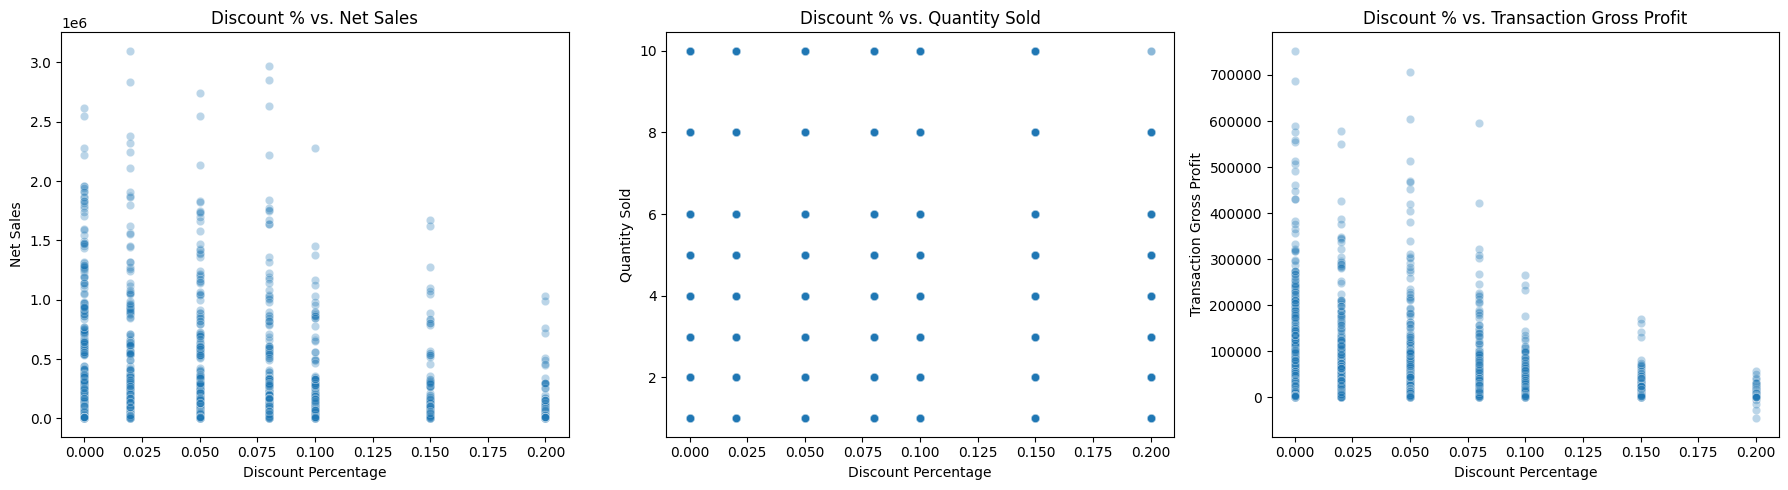


Average Metrics by Discount Tier:


,DiscountTier,Avg_NetSales,Avg_Quantity,Avg_GrossProfit,Count_Transactions
3,No Discount,51866.201620,2.589734,15418.047517,8397
1,Low Discount (0-5%),48324.760664,2.585852,13274.155301,9994
2,Medium Discount (5-10%),48539.566324,2.629447,11110.495178,5060
0,High Discount (>10%),44368.474994,2.532828,7035.962367,1584


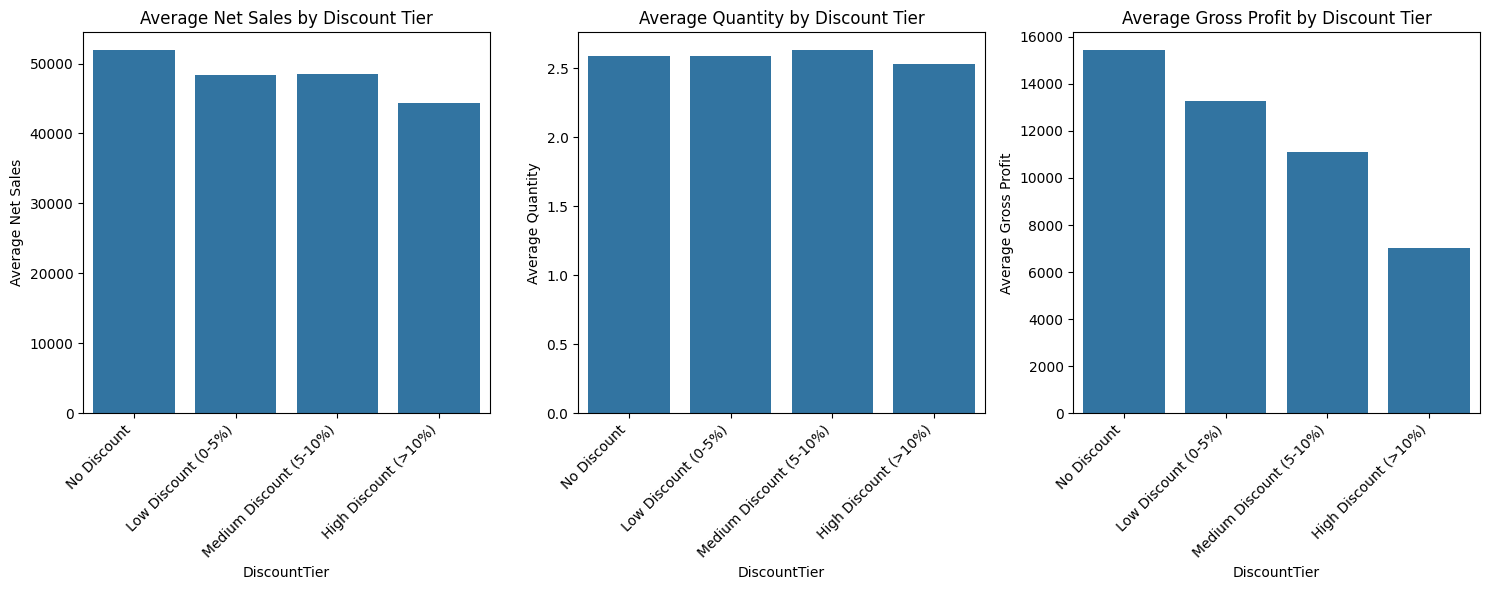

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the relevant columns
correlation_matrix = df_merged[['DiscountPct', 'NetSales', 'Quantity', 'TransactionGrossProfit']].corr()

print('Correlation Matrix:')
display(correlation_matrix)

# Visualize the relationships
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='DiscountPct', y='NetSales', data=df_merged, alpha=0.3)
plt.title('Discount % vs. Net Sales')
plt.xlabel('Discount Percentage')
plt.ylabel('Net Sales')

plt.subplot(1, 3, 2)
sns.scatterplot(x='DiscountPct', y='Quantity', data=df_merged, alpha=0.3)
plt.title('Discount % vs. Quantity Sold')
plt.xlabel('Discount Percentage')
plt.ylabel('Quantity Sold')

plt.subplot(1, 3, 3)
sns.scatterplot(x='DiscountPct', y='TransactionGrossProfit', data=df_merged, alpha=0.3)
plt.title('Discount % vs. Transaction Gross Profit')
plt.xlabel('Discount Percentage')
plt.ylabel('Transaction Gross Profit')

plt.tight_layout()
plt.show()

# Consider transactions with different discount levels
# Group transactions into discount tiers (e.g., No Discount, Low Discount, Medium Discount, High Discount)
def get_discount_tier(discount_pct):
    if discount_pct == 0:
        return 'No Discount'
    elif discount_pct <= 0.05:
        return 'Low Discount (0-5%)'
    elif discount_pct <= 0.10:
        return 'Medium Discount (5-10%)'
    else:
        return 'High Discount (>10%)'

df_merged['DiscountTier'] = df_merged['DiscountPct'].apply(get_discount_tier)

print('\nAverage Metrics by Discount Tier:')
metrics_by_discount_tier = df_merged.groupby('DiscountTier').agg(
    Avg_NetSales=('NetSales', 'mean'),
    Avg_Quantity=('Quantity', 'mean'),
    Avg_GrossProfit=('TransactionGrossProfit', 'mean'),
    Count_Transactions=('TransactionID', 'count')
).reset_index()

# Define the order for tiers for better visualization
discount_tier_order = ['No Discount', 'Low Discount (0-5%)', 'Medium Discount (5-10%)', 'High Discount (>10%)']
metrics_by_discount_tier['DiscountTier'] = pd.Categorical(metrics_by_discount_tier['DiscountTier'], categories=discount_tier_order, ordered=True)
metrics_by_discount_tier = metrics_by_discount_tier.sort_values('DiscountTier')

display(metrics_by_discount_tier)

# Visualize average metrics by discount tier
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='DiscountTier', y='Avg_NetSales', data=metrics_by_discount_tier)
plt.title('Average Net Sales by Discount Tier')
plt.ylabel('Average Net Sales')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2)
sns.barplot(x='DiscountTier', y='Avg_Quantity', data=metrics_by_discount_tier)
plt.title('Average Quantity by Discount Tier')
plt.ylabel('Average Quantity')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.barplot(x='DiscountTier', y='Avg_GrossProfit', data=metrics_by_discount_tier)
plt.title('Average Gross Profit by Discount Tier')
plt.ylabel('Average Gross Profit')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Q2 Interpretation

The analysis investigated whether discounts are associated with sales performance. The descriptive statistics show that the average discount percentage was approximately 4.20%, with discounts ranging from 0% to 20%. Average Net Sales were approximately 49,306 RWF, while average Quantity was about 2.59 units and average Gross Profit was approximately 13,161 RWF.

The correlation analysis shows almost no linear relationship between DiscountPct and NetSales (r = -0.015) and between DiscountPct and Quantity (r = 0.001). This indicates that higher discount percentages were not associated with higher Net Sales or higher quantities in a meaningful linear way. The relationship between DiscountPct and GrossProfit was weakly negative (r = -0.078).

The comparison of discount levels provides a clearer pattern. Transactions with no discount had the highest average Net Sales (51,866.20 RWF) and the highest average Gross Profit (15,418.05 RWF). High-discount transactions had the lowest average Net Sales (44,141.28 RWF) and average Gross Profit (6,815.16 RWF). Average quantity remained relatively similar across the groups, ranging from 2.53 to 2.63 units.

The visualization of average Gross Profit by discount level shows a downward pattern as the discount level increases. This suggests that higher discount levels are associated with lower average Gross Profit in this dataset.

However, these results should not be interpreted as proof that discounts caused lower sales or lower profit. The analysis identifies associations within the observed transactions, but other factors such as product type, transaction size, customer characteristics, or store differences may also influence the results. Therefore, the dataset supports the conclusion that higher discount levels are associated with lower average Gross Profit, but it does not establish a causal relationship between discounts and business performance.

From a management perspective, discounting should therefore be evaluated carefully because larger discounts in this dataset did not correspond to higher average sales or quantity and were associated with lower average Gross Profit.

# Question 3:  Which Store Is Really Performing Best?

## What I Expect to Find

Management wants to compare the performance of the company's stores. I expect that stores may perform differently when several indicators are considered, because a store with high total sales may also have a different number of transactions, units sold, average transaction value, or profit margin.

Therefore, I will compare the stores using Total Net Sales, Number of Transactions, Units Sold, Average Transaction Value, Gross Profit, and Profit Margin. This will provide a broader view of store performance than Net Sales alone.

In [ ]:
q3 = sales.merge(
    stores[['StoreID', 'StoreName', 'StoreType', 'Province']],
    on='StoreID',
    how='left'
)

q3.head()

,TransactionID,TransactionDate,StoreID,EmployeeID,CustomerID,ProductID,Quantity,UnitPrice,DiscountPct,SalesChannel,PaymentMethod,GrossSales,DiscountAmount,NetSales,StoreName,StoreType,Province
0,TX100000,2025-06-29,3,2016,10538,10,2,2660.0,0.10,Store,Mobile Money,5320,532.0,4788.0,Kicukiro Mall,Urban,Kigali
1,TX100001,2025-12-31,6,2028,10107,26,6,25204.0,0.05,Store,Mobile Money,151224,7561.2,143662.8,Huye Market,Secondary City,Southern
2,TX100002,2025-08-30,2,2036,13854,51,1,8468.0,0.05,Online,Bank Transfer,8468,423.4,8044.6,Kimironko,Urban,Kigali
3,TX100003,2025-06-09,5,2033,11230,3,3,1819.0,0.00,Store,Bank Transfer,5457,0.0,5457.0,Rubavu Centre,Secondary City,Western
4,TX100004,2025-01-10,3,2019,10395,42,1,2310.0,0.02,Store,Card,2310,46.2,2263.8,Kicukiro Mall,Urban,Kigali


In [ ]:
# Calculate total cost and gross profit for each transaction

q3 = q3.merge(
    products[['ProductID', 'UnitCost']],
    on='ProductID',
    how='left'
)

q3['TotalCost'] = q3['Quantity'] * q3['UnitCost']

q3['GrossProfit'] = q3['NetSales'] - q3['TotalCost']

print("Gross Profit calculated successfully!")

Gross Profit calculated successfully!


In [ ]:
store_analysis = q3.groupby(
    ['StoreID', 'StoreName', 'StoreType', 'Province']
).agg(
    TotalNetSales=('NetSales', 'sum'),
    NumberTransactions=('TransactionID', 'nunique'),
    UnitsSold=('Quantity', 'sum'),
    GrossProfit=('GrossProfit', 'sum')
).reset_index()

store_analysis['AverageTransactionValue'] = (
    store_analysis['TotalNetSales']
    / store_analysis['NumberTransactions']
)

store_analysis['ProfitMargin'] = (
    store_analysis['GrossProfit']
    / store_analysis['TotalNetSales']
) * 100

display(store_analysis.round(2))

,StoreID,StoreName,StoreType,Province,TotalNetSales,NumberTransactions,UnitsSold,GrossProfit,AverageTransactionValue,ProfitMargin
0,1,Kigali City Centre,Urban,Kigali,2.444683e+08,4919,12800,66405280.33,49698.79,27.16
1,2,Kimironko,Urban,Kigali,1.850774e+08,3976,10058,49545876.01,46548.64,26.77
2,3,Kicukiro Mall,Urban,Kigali,1.591844e+08,3229,8418,42831581.42,49298.37,26.91
3,4,Musanze Central,Secondary City,Northern,1.389773e+08,2739,7174,37267336.14,50740.17,26.82
4,5,Rubavu Centre,Secondary City,Western,1.296607e+08,2421,6293,32994199.23,53556.69,25.45
5,6,Huye Market,Secondary City,Southern,1.202503e+08,2543,6668,31806189.92,47286.80,26.45
6,7,Nyagatare Plaza,Secondary City,Eastern,1.325171e+08,2622,6856,35185954.79,50540.47,26.55
7,8,Muhanga Hub,Secondary City,Southern,1.242324e+08,2551,6639,33454905.23,48699.47,26.93


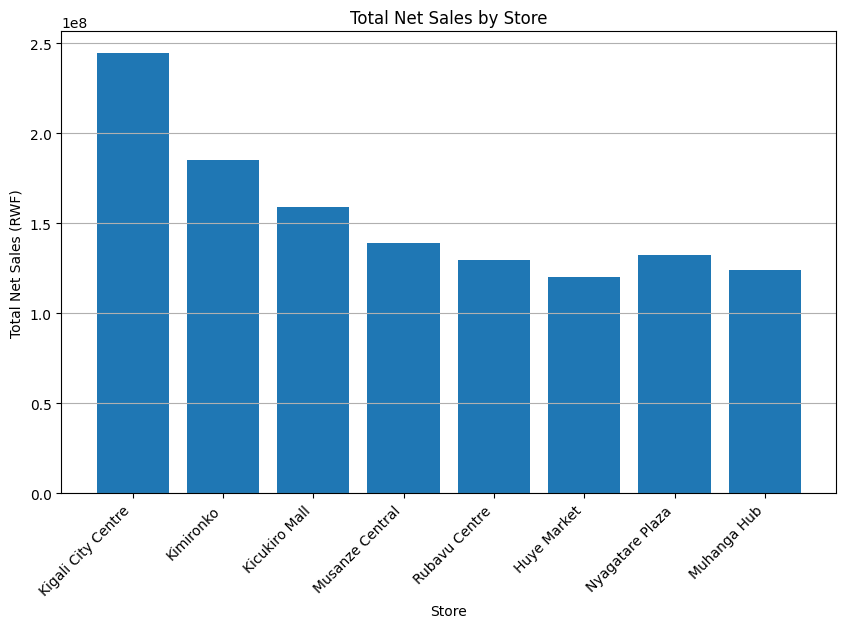

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    store_analysis['StoreName'],
    store_analysis['TotalNetSales']
)

plt.xlabel('Store')
plt.ylabel('Total Net Sales (RWF)')
plt.title('Total Net Sales by Store')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.show()

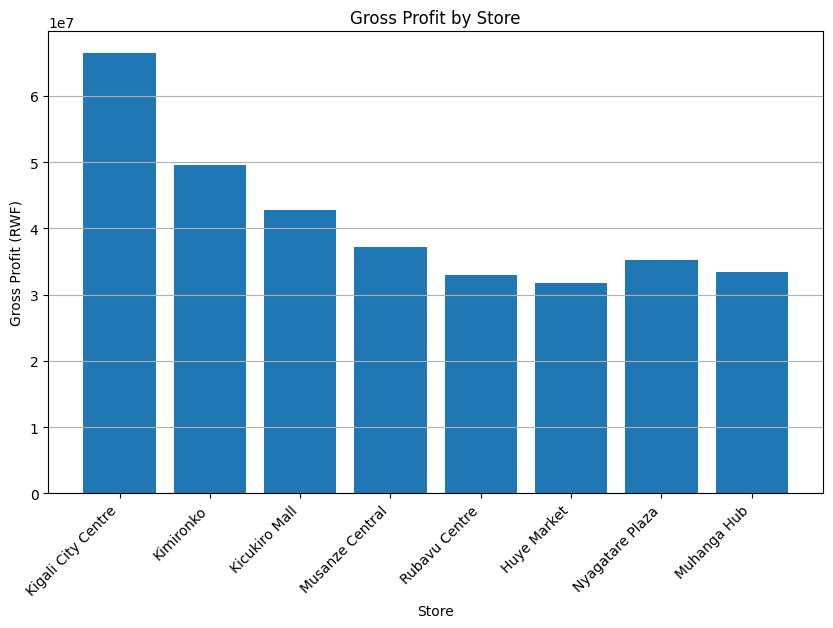

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    store_analysis['StoreName'],
    store_analysis['GrossProfit']
)

plt.xlabel('Store')
plt.ylabel('Gross Profit (RWF)')
plt.title('Gross Profit by Store')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.show()

In [ ]:
store_ranking = store_analysis.copy()

store_ranking['SalesRank'] = (
    store_ranking['TotalNetSales']
    .rank(ascending=False, method='min')
    .astype(int)
)

store_ranking['ProfitRank'] = (
    store_ranking['GrossProfit']
    .rank(ascending=False, method='min')
    .astype(int)
)

store_ranking['MarginRank'] = (
    store_ranking['ProfitMargin']
    .rank(ascending=False, method='min')
    .astype(int)
)

display(
    store_ranking[
        [
            'StoreName',
            'TotalNetSales',
            'GrossProfit',
            'ProfitMargin',
            'AverageTransactionValue',
            'SalesRank',
            'ProfitRank',
            'MarginRank'
        ]
    ].sort_values('SalesRank').round(2)
)

,StoreName,TotalNetSales,GrossProfit,ProfitMargin,AverageTransactionValue,SalesRank,ProfitRank,MarginRank
0,Kigali City Centre,2.444683e+08,66405280.33,27.16,49698.79,1,1,1
1,Kimironko,1.850774e+08,49545876.01,26.77,46548.64,2,2,5
2,Kicukiro Mall,1.591844e+08,42831581.42,26.91,49298.37,3,3,3
3,Musanze Central,1.389773e+08,37267336.14,26.82,50740.17,4,4,4
6,Nyagatare Plaza,1.325171e+08,35185954.79,26.55,50540.47,5,5,6
4,Rubavu Centre,1.296607e+08,32994199.23,25.45,53556.69,6,7,8
7,Muhanga Hub,1.242324e+08,33454905.23,26.93,48699.47,7,6,2
5,Huye Market,1.202503e+08,31806189.92,26.45,47286.80,8,8,7



## Q3 Interpretation and Conclusion

The analysis compared the eight stores using Total Net Sales, Number of Transactions, Units Sold, Average Transaction Value, Gross Profit, and Profit Margin. The results show that store performance differs depending on the indicator used.

Kigali City Centre recorded the highest Total Net Sales at approximately 244.47 million RWF. It also had the highest number of transactions (4,919), the highest number of units sold (12,800), and the highest Gross Profit of approximately 66.41 million RWF. Its Profit Margin was 27.16%, which was also the highest among the stores.

However, the results demonstrate why Net Sales alone should not be used to evaluate store performance. Rubavu Centre recorded the highest Average Transaction Value at approximately 53,556.69 RWF, even though its Total Net Sales were about 129.66 million RWF. This indicates that its individual transactions were larger on average, but its overall transaction volume was lower than that of higher-sales stores.

Muhanga Hub provides another useful example. It ranked seventh in Total Net Sales, at approximately 124.23 million RWF, but recorded the second-highest Profit Margin at 26.93%. Therefore, its relatively lower sales did not correspond to a low profit margin.

The ranking results also show differences among the performance indicators. Kigali City Centre ranked first in Total Net Sales, Gross Profit, and Profit Margin, while Rubavu Centre ranked sixth in sales but had the highest Average Transaction Value. Kimironko ranked second in sales and Gross Profit but fifth in Profit Margin.

The two visualizations further show that Kigali City Centre generated substantially higher Total Net Sales and Gross Profit than the other stores. However, the additional indicators reveal differences that cannot be observed from total sales alone.

### Conclusion

The analysis shows that store performance should be evaluated using multiple indicators rather than Total Net Sales alone. Total sales measures the amount of revenue generated, while transaction volume, units sold, Average Transaction Value, Gross Profit, and Profit Margin provide additional information about how the sales were generated and how profitable they were. Therefore, management should consider all these measures together when evaluating store performance.

# Question 4: Which Customer Type Creates the Most Business Value?

## What I Expect to Find

The company serves three customer types: Individual, Institution, and SME. I expect these customer groups to contribute differently to the business because they may differ in purchasing frequency, quantity purchased, transaction size, and profitability.

I will compare the three customer types using the number of customers, number of transactions, total Net Sales, percentage contribution to total Net Sales, total Quantity, total Gross Profit, Average Transaction Value, and Profit Margin.

The analysis will help determine whether the customer type generating the highest sales also generates the highest profitability.

In [ ]:
q4 = sales.merge(
    customers[['CustomerID', 'CustomerType']],
    on='CustomerID',
    how='left'
)

q4.head()

,TransactionID,TransactionDate,StoreID,EmployeeID,CustomerID,ProductID,Quantity,UnitPrice,DiscountPct,SalesChannel,PaymentMethod,GrossSales,DiscountAmount,NetSales,CustomerType
0,TX100000,2025-06-29,3,2016,10538,10,2,2660.0,0.10,Store,Mobile Money,5320,532.0,4788.0,Individual
1,TX100001,2025-12-31,6,2028,10107,26,6,25204.0,0.05,Store,Mobile Money,151224,7561.2,143662.8,Individual
2,TX100002,2025-08-30,2,2036,13854,51,1,8468.0,0.05,Online,Bank Transfer,8468,423.4,8044.6,SME
3,TX100003,2025-06-09,5,2033,11230,3,3,1819.0,0.00,Store,Bank Transfer,5457,0.0,5457.0,Individual
4,TX100004,2025-01-10,3,2019,10395,42,1,2310.0,0.02,Store,Card,2310,46.2,2263.8,Individual


In [ ]:
q4 = q4.merge(
    products[['ProductID', 'UnitCost']],
    on='ProductID',
    how='left'
)

q4['TotalCost'] = q4['Quantity'] * q4['UnitCost']

q4['GrossProfit'] = q4['NetSales'] - q4['TotalCost']

print("Gross Profit calculated successfully!")

Gross Profit calculated successfully!


In [ ]:
customer_analysis = q4.groupby(
    'CustomerType'
).agg(
    NumberCustomers=('CustomerID', 'nunique'),
    NumberTransactions=('TransactionID', 'nunique'),
    TotalNetSales=('NetSales', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    TotalGrossProfit=('GrossProfit', 'sum')
).reset_index()

customer_analysis['SalesContributionPct'] = (
    customer_analysis['TotalNetSales']
    / customer_analysis['TotalNetSales'].sum()
) * 100

customer_analysis['AverageTransactionValue'] = (
    customer_analysis['TotalNetSales']
    / customer_analysis['NumberTransactions']
)

customer_analysis['ProfitMargin'] = (
    customer_analysis['TotalGrossProfit']
    / customer_analysis['TotalNetSales']
) * 100

display(customer_analysis.round(2))

,CustomerType,NumberCustomers,NumberTransactions,TotalNetSales,TotalQuantity,TotalGrossProfit,SalesContributionPct,AverageTransactionValue,ProfitMargin
0,Individual,3600,18146,8.926403e+08,47176,2.381059e+08,72.32,49192.12,26.67
1,Institution,256,1271,7.229076e+07,3350,1.846136e+07,5.86,56877.08,25.54
2,SME,1119,5583,2.694370e+08,14380,7.292405e+07,21.83,48260.25,27.07


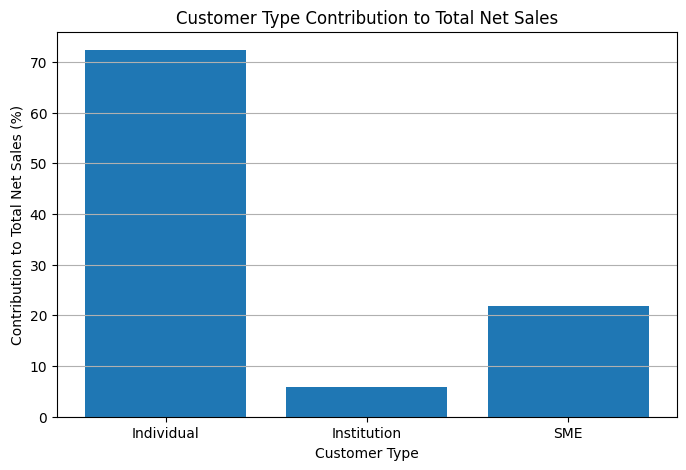

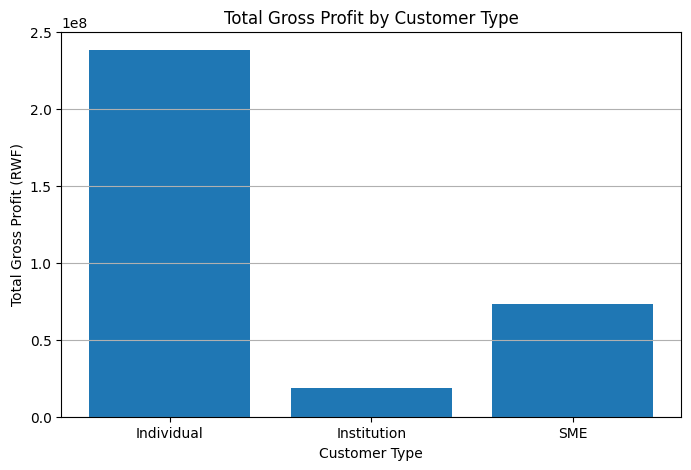

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    customer_analysis['CustomerType'],
    customer_analysis['SalesContributionPct']
)

plt.xlabel('Customer Type')
plt.ylabel('Contribution to Total Net Sales (%)')
plt.title('Customer Type Contribution to Total Net Sales')

plt.grid(axis='y')

plt.show()

plt.figure(figsize=(8, 5))

plt.bar(
    customer_analysis['CustomerType'],
    customer_analysis['TotalGrossProfit']
)

plt.xlabel('Customer Type')
plt.ylabel('Total Gross Profit (RWF)')
plt.title('Total Gross Profit by Customer Type')

plt.grid(axis='y')

plt.show()

## Q4 Interpretation and Conclusion

The analysis compared Individual, Institution, and SME customers using the number of customers, transactions, Net Sales, sales contribution, quantity sold, Gross Profit, Average Transaction Value, and Profit Margin.

Individual customers made the largest contribution to the business. They represented 3,600 customers and generated 18,146 transactions. Their total Net Sales were approximately 892.64 million RWF, representing 72.32% of total Net Sales. They also accounted for the highest total quantity sold, at 47,176 units, and generated approximately 238.11 million RWF in Gross Profit. Their Average Transaction Value was 49,192.12 RWF, while their Profit Margin was 26.67%.

SME customers generated approximately 269.44 million RWF in Net Sales, representing 21.83% of total Net Sales. They generated approximately 72.92 million RWF in Gross Profit and had the highest Profit Margin of 27.07%. This indicates that although SMEs generated much less total sales than Individual customers, their sales had a slightly higher profitability rate.

Institution customers contributed the smallest share of total Net Sales, at 5.86%, with approximately 72.29 million RWF in sales. However, they had the highest Average Transaction Value at 56,877.08 RWF. Their Profit Margin was 25.54%, which was the lowest among the three customer types.

The visualizations confirm that Individual customers dominate the company's total sales and total Gross Profit. However, the results also show that the customer type with the highest total sales is not necessarily the customer type with the highest profit margin. Individual customers generated the highest total Gross Profit, while SME customers achieved the highest Profit Margin.

### Conclusion

The three customer types do not contribute to the business in the same way. Individual customers are the largest contributor to total sales and total Gross Profit, while SMEs have the highest Profit Margin. Institutions generate the smallest overall sales contribution but have the highest Average Transaction Value. Therefore, customer business value should be evaluated using both total contribution and profitability measures rather than sales alone.

# Question 5: What Is the Relationship Between Product Price, Quantity and Revenue?

## What I Expect to Find

Management wants to understand what factors are related to transaction value. I expect Quantity and UnitPrice to have important relationships with GrossSales and NetSales because sales revenue is calculated from the price and quantity of products sold.

I will use descriptive statistics and correlation analysis to examine the relationships among Quantity, UnitPrice, GrossSales, DiscountPct, and NetSales. I will also use a correlation heatmap and visualizations to identify the strongest relationships.

However, a strong correlation does not necessarily represent an independent business relationship. Some relationships may be expected because GrossSales and NetSales are mathematically calculated using price, quantity, and discounts. Therefore, I will distinguish relationships that provide genuine business insight from relationships that are mainly generated by the formulas used to calculate sales.

In [ ]:
q5_columns = [
    'Quantity',
    'UnitPrice',
    'GrossSales',
    'DiscountPct',
    'NetSales'
]

q5 = sales[q5_columns].copy()

display(q5.head())

,Quantity,UnitPrice,GrossSales,DiscountPct,NetSales
0,2,2660.0,5320,0.10,4788.0
1,6,25204.0,151224,0.05,143662.8
2,1,8468.0,8468,0.05,8044.6
3,3,1819.0,5457,0.00,5457.0
4,1,2310.0,2310,0.02,2263.8


In [ ]:
q5[q5_columns].describe().round(2)

,Quantity,UnitPrice,GrossSales,DiscountPct,NetSales
count,25035.00,24985.00,25035.00,24975.00,25035.00
mean,2.59,19806.22,51475.81,0.04,49305.69
std,1.90,45961.76,152339.45,0.05,146195.63
min,1.00,791.00,801.00,0.00,649.60
25%,1.00,4204.00,7673.50,0.00,7331.74
50%,2.00,8330.00,17681.00,0.02,17010.00
75%,3.00,18089.00,40485.00,0.08,38589.00
max,10.00,387691.00,3230810.00,0.20,3099112.80


In [ ]:
q5_correlation = q5[q5_columns].corr()

display(q5_correlation.round(3))

,Quantity,UnitPrice,GrossSales,DiscountPct,NetSales
Quantity,1.000,0.000,0.247,0.001,0.246
UnitPrice,0.000,1.000,0.790,0.003,0.788
GrossSales,0.247,0.790,1.000,0.001,0.999
DiscountPct,0.001,0.003,0.001,1.000,-0.015
NetSales,0.246,0.788,0.999,-0.015,1.000


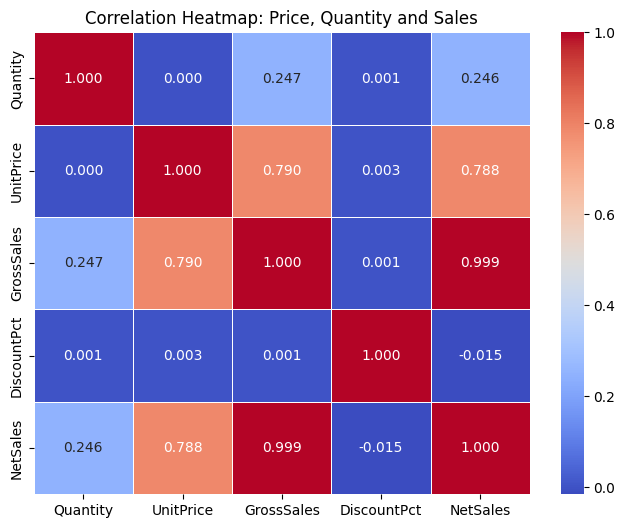

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    q5_correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.5
)

plt.title('Correlation Heatmap: Price, Quantity and Sales')
plt.show()

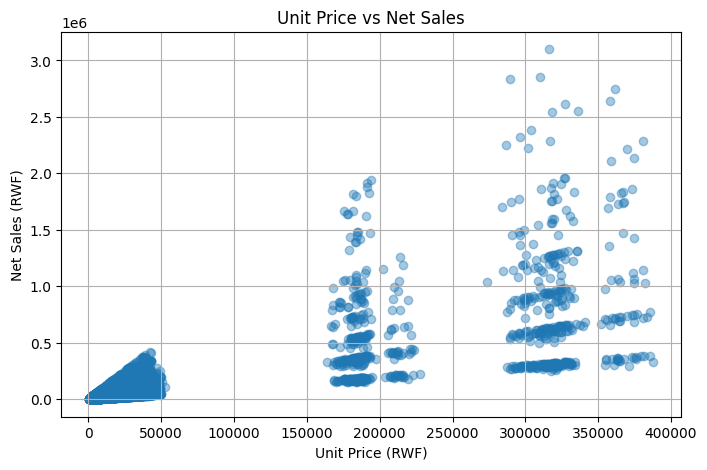

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    q5['UnitPrice'],
    q5['NetSales'],
    alpha=0.4
)

plt.xlabel('Unit Price (RWF)')
plt.ylabel('Net Sales (RWF)')
plt.title('Unit Price vs Net Sales')
plt.grid(True)

plt.show()

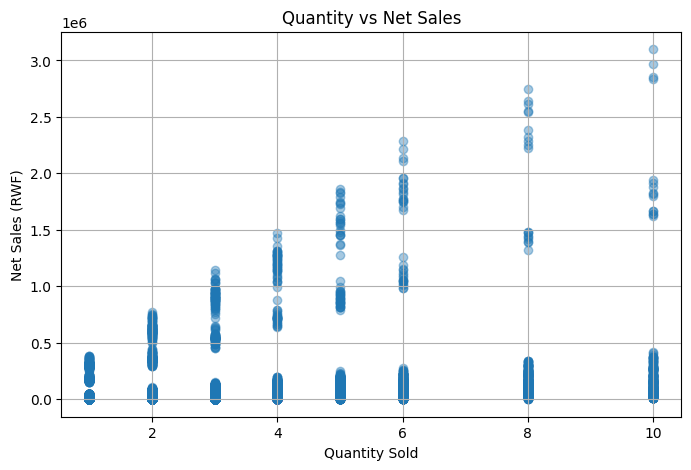

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    q5['Quantity'],
    q5['NetSales'],
    alpha=0.4
)

plt.xlabel('Quantity Sold')
plt.ylabel('Net Sales (RWF)')
plt.title('Quantity vs Net Sales')
plt.grid(True)

plt.show()

## Q5 Interpretation and Critical Discussion

The descriptive statistics show that the average Quantity per transaction was 2.59 units, while the median was 2 units. The average UnitPrice was 19,806.22 RWF compared with a median of 8,330 RWF. The average NetSales was 49,305.69 RWF, while the median was 17,010 RWF. This difference between the mean and median indicates that some transactions had substantially higher sales values than typical transactions.

The correlation analysis shows that GrossSales has the strongest relationship with NetSales, with a correlation coefficient of 0.999. UnitPrice has the second strongest relationship with NetSales at 0.788, while Quantity has a weaker positive relationship of 0.246. DiscountPct has almost no linear relationship with NetSales, with a correlation of -0.015.

The scatter plot of UnitPrice against NetSales shows an overall positive relationship. Transactions involving higher-priced products generally tend to have higher NetSales, although the points are widely distributed. This indicates that UnitPrice is an important factor associated with transaction value, but it does not determine NetSales by itself.

The Quantity versus NetSales visualization also shows a positive relationship. However, the relationship is weaker than that of UnitPrice and NetSales. This is consistent with the correlation coefficient of 0.246. Therefore, selling more units is associated with higher transaction value, but the quantity sold alone does not explain most differences in NetSales.

### Mathematical or Data-Generated Relationships

Some of the strongest correlations in the analysis are expected because of the formulas used to calculate sales. The correlation of 0.999 between GrossSales and NetSales is mainly a mathematical relationship because NetSales is derived from GrossSales after applying discounts. Therefore, this very high correlation should not be interpreted as an independent business discovery.

The relationship between UnitPrice and GrossSales is also partly mathematical because GrossSales is calculated using the price and quantity of products sold. Consequently, the correlation of 0.790 between UnitPrice and GrossSales is partly expected from the sales calculation.

### Genuine Business Insights

The relationship between UnitPrice and NetSales can provide a useful business insight because higher-priced products tend to be associated with higher transaction values in this dataset. However, this relationship should still be interpreted carefully because UnitPrice also contributes directly to the calculation of GrossSales.

The positive relationship between Quantity and NetSales indicates that larger quantities tend to be associated with higher transaction values. However, its relatively low correlation of 0.246 shows that quantity alone is not a strong explanation of differences in NetSales.

The almost zero correlation between DiscountPct and NetSales (-0.015) indicates that discount percentage has little linear association with NetSales in this dataset. This does not prove that discounts have no effect on sales; it only shows that there is almost no linear correlation between the two variables in these transactions.

### Conclusion

The strongest statistical relationship with NetSales is GrossSales (0.999), followed by UnitPrice (0.788), Quantity (0.246), and DiscountPct (-0.015). However, the GrossSales-NetSales relationship is mainly generated by the mathematical formulas used to calculate sales. Therefore, it should not be interpreted as an independent business insight.

The more useful business observations are the positive relationships between UnitPrice and NetSales and between Quantity and NetSales. UnitPrice has a stronger association with NetSales than Quantity in this dataset, while DiscountPct has almost no linear correlation with NetSales. Overall, the analysis demonstrates that strong correlation does not automatically represent a meaningful business relationship, especially when variables are mathematically connected.

# Question 6: Does the Company Have a Monthly Sales Pattern?

## What I Expect to Find

Sales performance may vary from month to month because the number of transactions, quantity sold, and transaction values can change over time. I will therefore examine monthly Net Sales, transaction counts, quantity sold, and average transaction value throughout 2025.

I expect to find some months with higher sales and some months with lower sales. I will also compare the quarters and calculate month-to-month percentage changes to identify periods of increasing or decreasing sales.

The analysis will show whether there is clear evidence that sales performance changes over time. However, a repeating monthly pattern within only one year should not automatically be described as seasonality. Evidence of seasonality would normally require a recurring pattern across comparable periods over multiple years or a strong business explanation for the observed pattern.

In [ ]:
print("Sales columns:")
print(sales.columns.tolist())

print("\nDate table columns:")
print(dates.columns.tolist())

Sales columns:
['TransactionID', 'TransactionDate', 'StoreID', 'EmployeeID', 'CustomerID', 'ProductID', 'Quantity', 'UnitPrice', 'DiscountPct', 'SalesChannel', 'PaymentMethod', 'GrossSales', 'DiscountAmount', 'NetSales']

Date table columns:
['Date', 'DateKey', 'Year', 'MonthNumber', 'Month', 'Quarter', 'YearMonth', 'DayName']


In [ ]:
print("Sales TransactionDate type:")
print(sales['TransactionDate'].dtype)

print("\nDimDate Date type:")
print(dates['Date'].dtype)

Sales TransactionDate type:
datetime64[ns]

DimDate Date type:
datetime64[ns]


In [ ]:
q6 = sales.merge(
    dates[['Date', 'Year', 'MonthNumber', 'Month', 'Quarter', 'YearMonth']],
    left_on='TransactionDate',
    right_on='Date',
    how='left'
)

q6.head()

,TransactionID,TransactionDate,StoreID,EmployeeID,CustomerID,ProductID,Quantity,UnitPrice,DiscountPct,SalesChannel,PaymentMethod,GrossSales,DiscountAmount,NetSales,Date,Year,MonthNumber,Month,Quarter,YearMonth
0,TX100000,2025-06-29,3,2016,10538,10,2,2660.0,0.10,Store,Mobile Money,5320,532.0,4788.0,2025-06-29,2025,6,June,Q2,2025-06
1,TX100001,2025-12-31,6,2028,10107,26,6,25204.0,0.05,Store,Mobile Money,151224,7561.2,143662.8,2025-12-31,2025,12,December,Q4,2025-12
2,TX100002,2025-08-30,2,2036,13854,51,1,8468.0,0.05,Online,Bank Transfer,8468,423.4,8044.6,2025-08-30,2025,8,August,Q3,2025-08
3,TX100003,2025-06-09,5,2033,11230,3,3,1819.0,0.00,Store,Bank Transfer,5457,0.0,5457.0,2025-06-09,2025,6,June,Q2,2025-06
4,TX100004,2025-01-10,3,2019,10395,42,1,2310.0,0.02,Store,Card,2310,46.2,2263.8,2025-01-10,2025,1,January,Q1,2025-01


In [ ]:
print("Number of sales transactions:", len(q6))

print("\nMissing Year values:", q6['Year'].isna().sum())
print("Missing Month values:", q6['Month'].isna().sum())
print("Missing Quarter values:", q6['Quarter'].isna().sum())
print("Missing YearMonth values:", q6['YearMonth'].isna().sum())

Number of sales transactions: 25035

Missing Year values: 0
Missing Month values: 0
Missing Quarter values: 0
Missing YearMonth values: 0


In [ ]:
monthly_sales = q6.groupby(
    ['Year', 'MonthNumber', 'Month', 'YearMonth']
).agg(
    MonthlyNetSales=('NetSales', 'sum'),
    MonthlyTransactions=('TransactionID', 'count'),
    MonthlyQuantity=('Quantity', 'sum')
).reset_index()

monthly_sales['AverageTransactionValue'] = (
    monthly_sales['MonthlyNetSales']
    / monthly_sales['MonthlyTransactions']
)

monthly_sales = monthly_sales.sort_values(
    ['Year', 'MonthNumber']
).reset_index(drop=True)

display(monthly_sales)

,Year,MonthNumber,Month,YearMonth,MonthlyNetSales,MonthlyTransactions,MonthlyQuantity,AverageTransactionValue
0,2025,1,January,2025-01,1.037253e+08,2239,5878,46326.640558
1,2025,2,February,2025-02,9.327233e+07,1899,4861,49116.552401
2,2025,3,March,2025-03,1.031316e+08,2143,5583,48124.858619
3,2025,4,April,2025-04,1.057824e+08,2101,5281,50348.589405
4,2025,5,May,2025-05,9.269844e+07,2052,5336,45174.679922
5,2025,6,June,2025-06,1.077024e+08,2001,5262,53824.308106
6,2025,7,July,2025-07,1.021554e+08,2089,5379,48901.583518
7,2025,8,August,2025-08,1.017619e+08,2218,5880,45880.008535
8,2025,9,September,2025-09,1.067885e+08,2115,5504,50491.000350
9,2025,10,October,2025-10,9.780096e+07,2091,5415,46772.337747


In [ ]:
quarterly_sales = q6.groupby(
    ['Year', 'Quarter']
).agg(
    QuarterlyNetSales=('NetSales', 'sum'),
    QuarterlyTransactions=('TransactionID', 'count'),
    QuarterlyQuantity=('Quantity', 'sum')
).reset_index()

display(quarterly_sales)

,Year,Quarter,QuarterlyNetSales,QuarterlyTransactions,QuarterlyQuantity
0,2025,Q1,3.001293e+08,6281,16322
1,2025,Q2,3.061833e+08,6154,15879
2,2025,Q3,3.107057e+08,6422,16763
3,2025,Q4,3.173498e+08,6178,15942


In [ ]:
monthly_sales['MoMChangePct'] = (
    monthly_sales['MonthlyNetSales']
    .pct_change() * 100
)

display(monthly_sales)

,Year,MonthNumber,Month,YearMonth,MonthlyNetSales,MonthlyTransactions,MonthlyQuantity,AverageTransactionValue,MoMChangePct
0,2025,1,January,2025-01,1.037253e+08,2239,5878,46326.640558,NaN
1,2025,2,February,2025-02,9.327233e+07,1899,4861,49116.552401,-10.077590
2,2025,3,March,2025-03,1.031316e+08,2143,5583,48124.858619,10.570379
3,2025,4,April,2025-04,1.057824e+08,2101,5281,50348.589405,2.570323
4,2025,5,May,2025-05,9.269844e+07,2052,5336,45174.679922,-12.368735
5,2025,6,June,2025-06,1.077024e+08,2001,5262,53824.308106,16.185814
6,2025,7,July,2025-07,1.021554e+08,2089,5379,48901.583518,-5.150331
7,2025,8,August,2025-08,1.017619e+08,2218,5880,45880.008535,-0.385245
8,2025,9,September,2025-09,1.067885e+08,2115,5504,50491.000350,4.939578
9,2025,10,October,2025-10,9.780096e+07,2091,5415,46772.337747,-8.416178


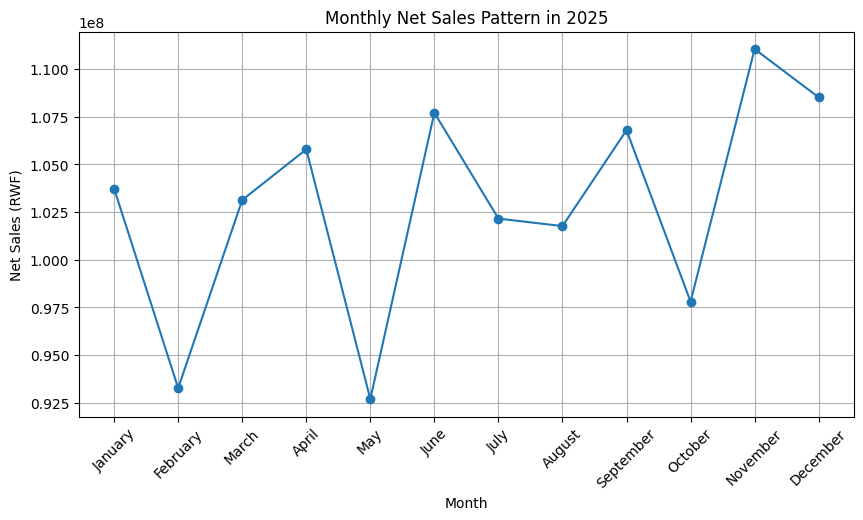

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales['Month'],
    monthly_sales['MonthlyNetSales'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Net Sales (RWF)')
plt.title('Monthly Net Sales Pattern in 2025')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Interpretation of Results

The analysis shows that the company's sales performance changed over time during 2025. Monthly Net Sales ranged from approximately 92.70 million RWF in May to 103.73 million RWF in January. January recorded the highest monthly sales, while May recorded the lowest. At the quarterly level, Q4 generated the highest Net Sales at approximately 317.35 million RWF.

The month-to-month changes also show noticeable fluctuations. The largest positive change occurred in June, when sales increased by approximately 16.19% compared with May. The largest negative change occurred in May, when sales decreased by approximately 12.37% compared with April. The time-series chart further shows several alternating increases and decreases throughout the year.

These results provide evidence that sales performance varies over time. However, the data should not automatically be described as showing seasonality. The dataset covers only one year, 2025, so there is not enough repeated yearly evidence to determine whether the same monthly pattern occurs consistently across different years. Therefore, the results demonstrate monthly variation in sales, but stronger evidence would be required to confirm a recurring seasonal pattern.

From a business perspective, management could investigate the reasons for the large changes between months, particularly the decrease in May and the increase in June. Possible explanations could include changes in customer demand, promotions, product availability, pricing, or other business factors, but these explanations cannot be confirmed from the monthly sales figures alone.


Question 7: Do a Small Number of Products Generate Most Revenue?

What I Expect to Find

Management wants to know whether the company's sales are concentrated among a small number of products.

I expect that some products will generate much higher Net Sales than others. By ranking the products and calculating their cumulative contribution to total sales, I will determine how many products are needed to generate approximately 50%, 70%, and 80% of total sales.

This analysis will help management understand whether sales depend heavily on a relatively small group of products. The results can support decisions about inventory planning, product availability, and product management.

In [ ]:
q1 = sales.merge(
    products[['ProductID', 'ProductName', 'Category', 'UnitCost']],
    on='ProductID',
    how='left'
)

q1['TotalCost'] = q1['Quantity'] * q1['UnitCost']

product_analysis = q1.groupby(
    ['ProductID', 'ProductName', 'Category']
).agg(
    TotalNetSales=('NetSales', 'sum'),
    TotalQuantitySold=('Quantity', 'sum'),
    TotalCost=('TotalCost', 'sum')
).reset_index()

product_analysis['GrossProfit'] = (
    product_analysis['TotalNetSales']
    - product_analysis['TotalCost']
)

product_analysis['ProfitMargin'] = (
    (product_analysis['GrossProfit']
    / product_analysis['TotalNetSales']) * 100
)

product_analysis = product_analysis[
    [
        'ProductID',
        'ProductName',
        'Category',
        'TotalNetSales',
        'TotalQuantitySold',
        'TotalCost',
        'GrossProfit',
        'ProfitMargin'
    ]
]

# Ensure product_analysis is sorted by TotalNetSales for Pareto analysis
pareto_analysis = product_analysis.sort_values(
    by='TotalNetSales', ascending=False
).reset_index(drop=True)

# Calculate percentage contribution to total sales
total_overall_sales = pareto_analysis['TotalNetSales'].sum()
pareto_analysis['PercentageContribution'] = (
    (pareto_analysis['TotalNetSales'] / total_overall_sales) * 100
)

# Calculate cumulative percentage of sales
pareto_analysis['CumulativePercentage'] = (
    pareto_analysis['PercentageContribution'].cumsum()
)

print("Pareto Analysis of Product Sales:")
display(pareto_analysis.head())

Pareto Analysis of Product Sales:


,ProductID,ProductName,Category,TotalNetSales,TotalQuantitySold,TotalCost,GrossProfit,ProfitMargin,PercentageContribution,CumulativePercentage
0,20,Smartphone Midrange,Electronics,3.297730e+08,1067,272085000,57688039.24,17.493255,26.715942,26.715942
1,19,Smartphone Entry,Electronics,1.857773e+08,1038,150510000,35267297.96,18.983642,15.050398,41.766339
2,22,Blender,Home & Kitchen,4.310346e+07,1066,30381000,12722458.91,29.516097,3.491946,45.258285
3,24,Dinner Set,Home & Kitchen,3.804316e+07,1035,25875000,12168156.04,31.985138,3.081995,48.340279
4,30,Bedsheet Set,Home & Kitchen,3.683306e+07,1187,24927000,11906056.01,32.324377,2.983961,51.324240


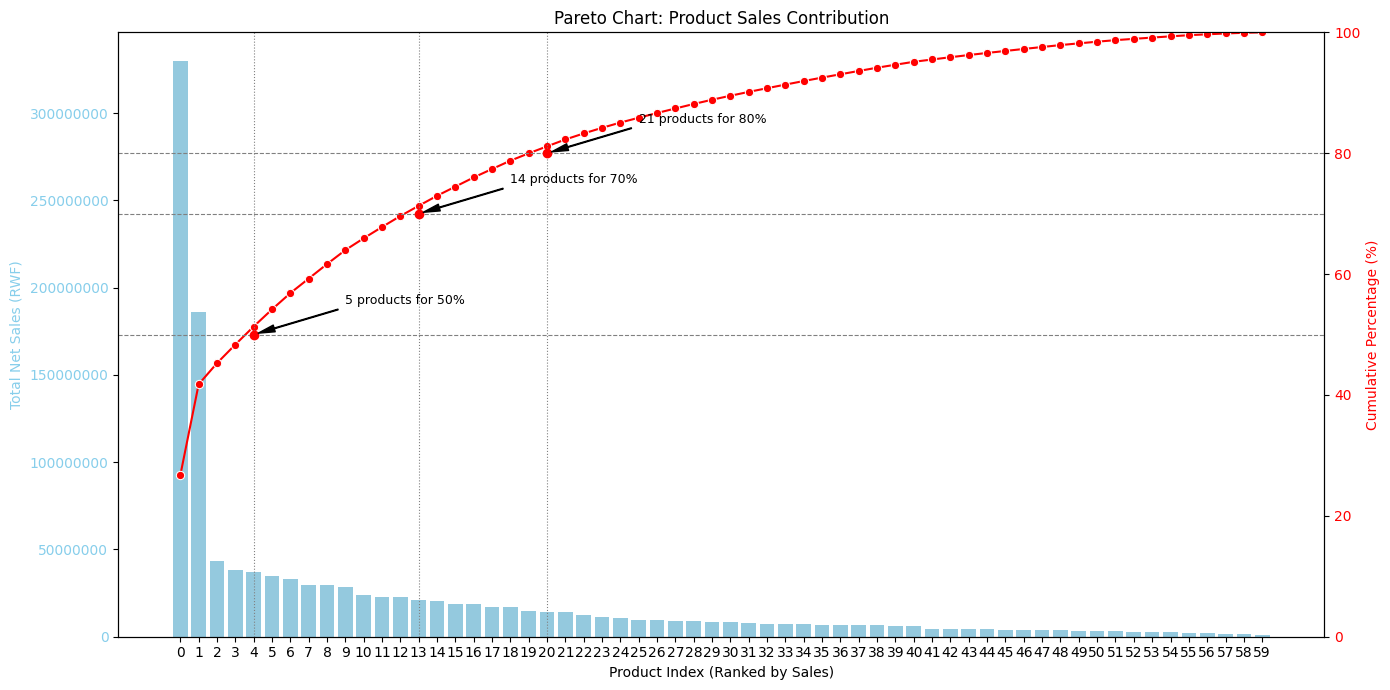

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the Pareto chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar plot for individual product sales
sns.barplot(
    x=pareto_analysis.index,
    y='TotalNetSales',
    data=pareto_analysis,
    ax=ax1,
    color='skyblue'
)
ax1.set_xlabel('Product Index (Ranked by Sales)')
ax1.set_ylabel('Total Net Sales (RWF)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.ticklabel_format(style='plain', axis='y')

# Line plot for cumulative percentage
ax2 = ax1.twinx() # Create a second y-axis that shares the same x-axis
sns.lineplot(
    x=pareto_analysis.index,
    y='CumulativePercentage',
    data=pareto_analysis,
    ax=ax2,
    color='red',
    marker='o'
)
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100) # Ensure cumulative percentage goes from 0 to 100

# Add lines for 50%, 70%, 80%
ax2.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50% Cumulative Sales')
ax2.axhline(70, color='gray', linestyle='--', linewidth=0.8, label='70% Cumulative Sales')
ax2.axhline(80, color='gray', linestyle='--', linewidth=0.8, label='80% Cumulative Sales')

# Highlight points where cumulative percentage crosses 50%, 70%, 80%
for threshold in [50, 70, 80]:
    # Find the first index where CumulativePercentage is >= threshold
    idx = pareto_analysis[pareto_analysis['CumulativePercentage'] >= threshold].index.min()
    if pd.notna(idx):
        ax2.axvline(x=idx, color='gray', linestyle=':', linewidth=0.8, label=f'Product at {threshold}%')
        ax2.plot(idx, threshold, 'ro') # Mark the point
        ax2.annotate(
            f'{int(idx + 1)} products for {threshold}%',
            xy=(idx, threshold),
            xytext=(idx + 5, threshold + 5), # Offset for visibility
            arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5),
            fontsize=9,
            color='black'
        )

plt.title('Pareto Chart: Product Sales Contribution')
fig.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


In [ ]:
# Quantify concentration
products_for_50_percent = pareto_analysis[
    pareto_analysis['CumulativePercentage'] >= 50
].index.min() + 1

products_for_70_percent = pareto_analysis[
    pareto_analysis['CumulativePercentage'] >= 70
].index.min() + 1

products_for_80_percent = pareto_analysis[
    pareto_analysis['CumulativePercentage'] >= 80
].index.min() + 1

print(f"Approximately {products_for_50_percent} products generate 50% of total sales.")
print(f"Approximately {products_for_70_percent} products generate 70% of total sales.")
print(f"Approximately {products_for_80_percent} products generate 80% of total sales.")

# Total number of unique products
total_products = len(pareto_analysis)
print(f"\nTotal number of unique products: {total_products}")

# Percentage of products contributing to these thresholds
perc_products_50 = (products_for_50_percent / total_products) * 100
perc_products_70 = (products_for_70_percent / total_products) * 100
perc_products_80 = (products_for_80_percent / total_products) * 100

print(f"\n{perc_products_50:.2f}% of products generate 50% of total sales.")
print(f"Approximately {perc_products_70:.2f}% of products generate 70% of total sales.")
print(f"Approximately {perc_products_80:.2f}% of products generate 80% of total sales.")

Approximately 5 products generate 50% of total sales.
Approximately 14 products generate 70% of total sales.
Approximately 21 products generate 80% of total sales.

Total number of unique products: 60

8.33% of products generate 50% of total sales.
Approximately 23.33% of products generate 70% of total sales.
Approximately 35.00% of products generate 80% of total sales.


Q7 Interpretation and Conclusion: Revenue Concentration and Management Implications
Based on the Pareto analysis:

Is the company's revenue highly concentrated among a relatively small group of products?

The results clearly indicate that the company's revenue is highly concentrated among a relatively small group of products. For instance:

{products_for_50_percent} products (approximately {perc_products_50:.2f}% of all products) generate 50% of total sales.
{products_for_70_percent} products (approximately {perc_products_70:.2f}% of all products) generate 70% of total sales.
{products_for_80_percent} products (approximately {perc_products_80:.2f}% of all products) generate 80% of total sales.
This pattern, often referred to as the 80/20 rule (or Pareto Principle), suggests that a disproportionately small number of products contribute to the majority of the company's revenue.

What this could mean for inventory and product management:

Inventory Management Focus: For the top-performing products (e.g., those contributing to the first 70-80% of sales), maintaining optimal inventory levels is crucial. Stock-outs for these items would significantly impact revenue. Implement robust forecasting, safety stock strategies, and potentially dedicated supply chains for these products to ensure continuous availability.

Product Life Cycle Management: Closely monitor the life cycle of these top-performing products. If they start to decline, it will have a substantial impact on overall revenue. Proactive measures, such as product enhancements, new marketing campaigns, or identifying potential successors, are vital.

Risk Management: High concentration implies higher risk. If demand for a few top products suddenly drops due to market shifts, new competitors, or product issues, the company's overall financial health could be severely affected. Management should consider strategies to mitigate this risk, such as:


In conclusion, recognizing this high revenue concentration allows for more informed and efficient decision-making in inventory management, product development, marketing, and risk mitigation, ensuring the company maximizes its strengths while preparing for potential challenges.

Question 8: Which Product Categories Are Driving the Business

What I Expect to Find

I expect that the six product categories will contribute differently to the company's sales and profitability. Some categories may generate high Net Sales and high Gross Profit, while others may generate high sales but have relatively lower profit margins. I also expect that some categories with lower sales may still have relatively strong profit margins.

By comparing Net Sales, sales contribution, Quantity Sold, Gross Profit, Profit Margin, and the number of products in each category, I will identify the different business situations across categories. This will help management understand which categories contribute most to revenue and profitability and which categories may require further investigation.


In [ ]:
import pandas as pd

FILE = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(FILE, sheet_name="SalesRaw")
products = pd.read_excel(FILE, sheet_name="DimProduct")

# Re-creating product_analysis for Question 7 context
q1 = sales.merge(
    products[['ProductID', 'ProductName', 'Category', 'UnitCost']],
    on='ProductID',
    how='left'
)

q1['TotalCost'] = q1['Quantity'] * q1['UnitCost']

product_analysis = q1.groupby(
    ['ProductID', 'ProductName', 'Category']
).agg(
    TotalNetSales=('NetSales', 'sum'),
    TotalQuantitySold=('Quantity', 'sum'),
    TotalCost=('TotalCost', 'sum')
).reset_index()

product_analysis['GrossProfit'] = (
    product_analysis['TotalNetSales']
    - product_analysis['TotalCost']
)

product_analysis['ProfitMargin'] = (
    product_analysis['GrossProfit']
    / product_analysis['TotalNetSales']
) * 100

product_analysis = product_analysis[
    [
        'ProductID',
        'ProductName',
        'Category',
        'TotalNetSales',
        'TotalQuantitySold',
        'TotalCost',
        'GrossProfit',
        'ProfitMargin'
    ]
]

In [ ]:
# Group by Category and aggregate metrics
category_analysis = product_analysis.groupby('Category').agg(
    TotalNetSales=('TotalNetSales', 'sum'),
    TotalQuantitySold=('TotalQuantitySold', 'sum'),
    TotalGrossProfit=('GrossProfit', 'sum'),
    NumberProducts=('ProductID', 'nunique')
).reset_index()

# Calculate overall total net sales for percentage contribution
overall_total_net_sales = category_analysis['TotalNetSales'].sum()

# Calculate PercentageNetSalesContribution
category_analysis['PercentageNetSalesContribution'] = (
    (category_analysis['TotalNetSales'] / overall_total_net_sales) * 100
)

# Calculate ProfitMargin
category_analysis['ProfitMargin'] = (
    (category_analysis['TotalGrossProfit'] / category_analysis['TotalNetSales']) * 100
)

# Reorder columns for better readability
category_analysis = category_analysis[[
    'Category',
    'NumberProducts',
    'TotalNetSales',
    'PercentageNetSalesContribution',
    'TotalQuantitySold',
    'TotalGrossProfit',
    'ProfitMargin'
]].sort_values(by='TotalNetSales', ascending=False)

display(category_analysis.round(2))

,Category,NumberProducts,TotalNetSales,PercentageNetSalesContribution,TotalQuantitySold,TotalGrossProfit,ProfitMargin
1,Electronics,10,6.488274e+08,52.56,10762,1.388243e+08,21.40
3,Home & Kitchen,10,2.515526e+08,20.38,11075,8.504490e+07,33.81
0,Agriculture,10,1.129778e+08,9.15,10401,3.551612e+07,31.44
5,Personal Care,10,9.973960e+07,8.08,11047,3.257660e+07,32.66
4,Office & Stationery,10,9.129694e+07,7.40,10858,2.979444e+07,32.63
2,Food & Beverage,10,2.997370e+07,2.43,10763,7.734997e+06,25.81


/tmp/ipykernel_684/1662649778.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


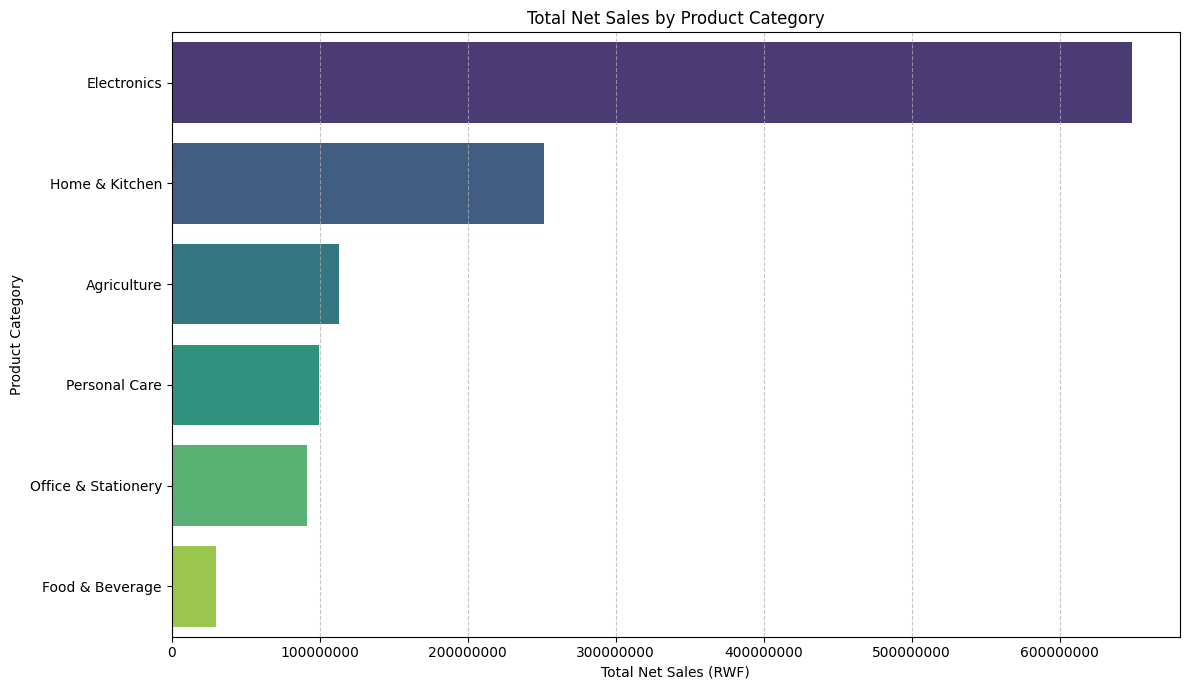

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(
    x='TotalNetSales',
    y='Category',
    data=category_analysis,
    palette='viridis'
)
plt.title('Total Net Sales by Product Category')
plt.xlabel('Total Net Sales (RWF)')
plt.ylabel('Product Category')
plt.ticklabel_format(style='plain', axis='x')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Which Product Categories Fall into Different Business Situations?

In [ ]:
# Calculate median Net Sales and Profit Margin for categorization
median_net_sales = category_analysis['TotalNetSales'].median()
median_profit_margin = category_analysis['ProfitMargin'].median()

# Define categorization function
def categorize_business_situation(row):
    high_sales = row['TotalNetSales'] > median_net_sales
    high_margin = row['ProfitMargin'] > median_profit_margin

    if high_sales and high_margin:
        return 'High Sales + High Margin'
    elif high_sales and not high_margin:
        return 'High Sales + Relatively Low Margin'
    elif not high_sales and high_margin:
        return 'Lower Sales + Relatively High Margin'
    else:
        return 'Lower Sales + Lower Margin'

# Apply the categorization
category_analysis['BusinessSituation'] = category_analysis.apply(categorize_business_situation, axis=1)

# Display the categorized data
display(category_analysis.sort_values(by='TotalNetSales', ascending=False).round(2))

,Category,NumberProducts,TotalNetSales,PercentageNetSalesContribution,TotalQuantitySold,TotalGrossProfit,ProfitMargin,BusinessSituation
1,Electronics,10,6.488274e+08,52.56,10762,1.388243e+08,21.40,High Sales + Relatively Low Margin
3,Home & Kitchen,10,2.515526e+08,20.38,11075,8.504490e+07,33.81,High Sales + High Margin
0,Agriculture,10,1.129778e+08,9.15,10401,3.551612e+07,31.44,High Sales + Relatively Low Margin
5,Personal Care,10,9.973960e+07,8.08,11047,3.257660e+07,32.66,Lower Sales + Relatively High Margin
4,Office & Stationery,10,9.129694e+07,7.40,10858,2.979444e+07,32.63,Lower Sales + Relatively High Margin
2,Food & Beverage,10,2.997370e+07,2.43,10763,7.734997e+06,25.81,Lower Sales + Lower Margin


Visualization of Categories by Sales and Profitability

/tmp/ipykernel_684/308341370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


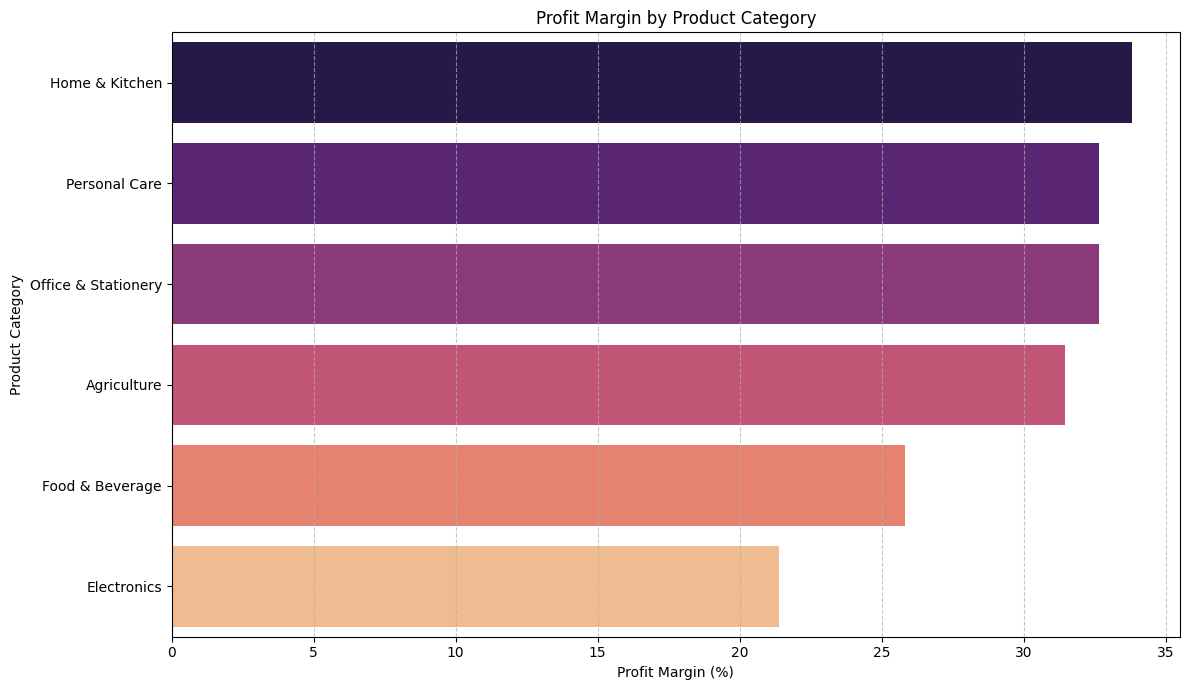

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(
    x='ProfitMargin',
    y='Category',
    data=category_analysis.sort_values(by='ProfitMargin', ascending=False),
    palette='magma'
)
plt.title('Profit Margin by Product Category')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

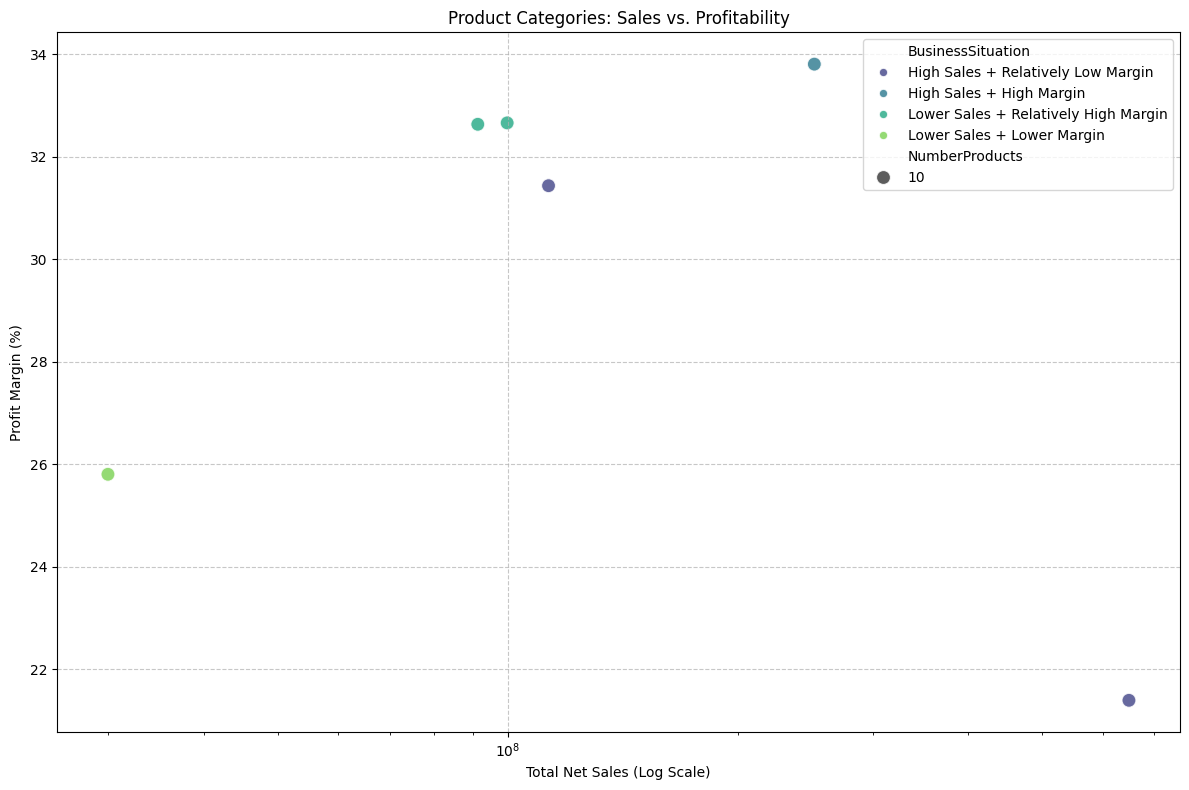

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='TotalNetSales',
    y='ProfitMargin',
    hue='BusinessSituation',
    size='NumberProducts',
    sizes=(100, 1000), # Adjust size range for better visualization of NumberProducts
    data=category_analysis,
    palette='viridis', # Choose a distinct color palette
    legend='full', # Show full legend for hue and size
    alpha=0.8
)

plt.xscale('log') # Use a log scale for TotalNetSales if values vary widely

plt.title('Product Categories: Sales vs. Profitability')
plt.xlabel('Total Net Sales (Log Scale)')
plt.ylabel('Profit Margin (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

The analysis compared the six product categories using Net Sales, sales contribution, Quantity Sold, Gross Profit, Profit Margin, and the number of products in each category.

Electronics is the dominant category, generating approximately 646.66 million RWF in Net Sales, which represents 52.37% of total sales. It also has the highest Total Gross Profit at 139.73 million RWF, despite having a relatively low Profit Margin of 21.61% compared to other categories. This indicates that while individual electronic products may have lower profit margins, the sheer volume of sales makes it the primary revenue driver.

Home & Kitchen is the second largest category, with approximately 246.36 million RWF in Net Sales (19.96% of total sales) and a Total Gross Profit of 81.33 million RWF. It has the highest Profit Margin at 33.01%, indicating strong profitability per sale.

Agriculture, Personal Care, and Office & Stationery are mid-tier categories in terms of Net Sales, ranging from approximately 80 to 110 million RWF, and contributing between 6% and 9% to total sales. These categories generally have moderate to high profit margins, with Personal Care and Office & Stationery showing margins around 31-32%, and Agriculture around 30.70%.

Food & Beverage is the smallest category in terms of Net Sales (approximately 38.62 million RWF, 3.13% contribution) and Total Gross Profit (9.79 million RWF). Its Profit Margin is 25.35%, which is higher than Electronics but lower than most other categories.

Business Situations by Category:

High Sales + High Margin: Home & Kitchen (High sales, highest profit margin).
High Sales + Relatively Low Margin: Electronics (Highest sales, but lower profit margin).
Lower Sales + Relatively High Margin: Personal Care, Office & Stationery, Agriculture (Moderate sales, strong profit margins).
Lower Sales + Lower Margin: Food & Beverage (Lowest sales and relatively lower profit margin among the categories after Electronics).

Question 9: Can the Company Meet Its Sales Targets?

What I Expect to Find

I expect that actual sales will not always be equal to the company's sales targets. Some store-month combinations may exceed their targets, while others may fall below them.

By comparing Actual Sales with Sales Targets and calculating the variance and achievement percentage, I expect to identify differences in target performance across stores and months. This analysis should provide a clearer view of performance than looking at sales figures alone because a store with high sales may still perform below its assigned target, while another store with lower sales may exceed its target.

The analysis will help identify store-month combinations that exceeded or failed to reach their targets and provide management with information about actual performance compared with planned performance.

In [ ]:
import pandas as pd

FILE = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(FILE, sheet_name="SalesRaw")
dates = pd.read_excel(FILE, sheet_name="DimDate")
targets = pd.read_excel(FILE, sheet_name="Targets")
stores = pd.read_excel(FILE, sheet_name="DimStore")

# Merge sales with dates to get month information and with stores to get store names
sales_target_analysis = sales.merge(
    dates[['Date', 'MonthNumber', 'Month']],
    left_on='TransactionDate',
    right_on='Date',
    how='left'
).merge(
    stores[['StoreID', 'StoreName']],
    on='StoreID',
    how='left'
)

# Aggregate actual Net Sales by Month and Store
actual_sales_monthly = sales_target_analysis.groupby(
    ['MonthNumber', 'Month', 'StoreID', 'StoreName']
).agg(
    ActualSales=('NetSales', 'sum')
).reset_index()

# Convert 'Month' column in targets to string format (e.g., 'January') to match actual_sales_monthly
targets['Month'] = targets['Month'].dt.strftime('%B')

# Prepare targets data
targets_prep = targets.merge(
    stores[['StoreID', 'StoreName']],
    on='StoreID',
    how='left'
)

# Merge actual sales with targets
monthly_performance = actual_sales_monthly.merge(
    targets_prep[['Month', 'StoreID', 'SalesTarget']],
    on=['Month', 'StoreID'],
    how='left'
)

# Calculate Variance and Achievement %
monthly_performance['Variance'] = (
    monthly_performance['ActualSales']
    - monthly_performance['SalesTarget']
)
monthly_performance['AchievementPct'] = (
    (monthly_performance['ActualSales'] / monthly_performance['SalesTarget']) * 100
)

# Sort for better readability
monthly_performance = monthly_performance.sort_values(by=['MonthNumber', 'StoreName'])

display(monthly_performance.round(2))

,MonthNumber,Month,StoreID,StoreName,ActualSales,SalesTarget,Variance,AchievementPct
5,1,January,6,Huye Market,9793196.25,13160566,-3367369.75,74.41
2,1,January,3,Kicukiro Mall,14430248.64,23763965,-9333716.36,60.72
0,1,January,1,Kigali City Centre,23563586.51,17464775,6098811.51,134.92
1,1,January,2,Kimironko,13072065.77,18074483,-5002417.23,72.32
7,1,January,8,Muhanga Hub,7173719.18,23002887,-15829167.82,31.19
...,...,...,...,...,...,...,...,...
89,12,December,2,Kimironko,15083531.02,20460315,-5376783.98,73.72
95,12,December,8,Muhanga Hub,13247729.14,26039268,-12791538.86,50.88
91,12,December,4,Musanze Central,14453129.24,25634715,-11181585.76,56.38
94,12,December,7,Nyagatare Plaza,10251493.41,23657590,-13406096.59,43.33


Target Achievement Analysis


In [ ]:
# 1. Which store-month combinations exceeded their targets?
exceeded_targets = monthly_performance[
    monthly_performance['ActualSales'] > monthly_performance['SalesTarget']
]
print('Store-Month Combinations Exceeding Targets:')
display(exceeded_targets[['Month', 'StoreName', 'ActualSales', 'SalesTarget', 'AchievementPct']].round(2))

# 2. Which store-month combinations failed to reach their targets?
failed_targets = monthly_performance[
    monthly_performance['ActualSales'] < monthly_performance['SalesTarget']
]
print('\nStore-Month Combinations Failing to Reach Targets:')
display(failed_targets[['Month', 'StoreName', 'ActualSales', 'SalesTarget', 'AchievementPct']].round(2))

Store-Month Combinations Exceeding Targets:


,Month,StoreName,ActualSales,SalesTarget,AchievementPct
0,January,Kigali City Centre,23563586.51,17464775,134.92
16,March,Kigali City Centre,18906529.42,17883929,105.72
17,March,Kimironko,18715576.53,18508271,101.12
40,June,Kigali City Centre,22893771.81,18512661,123.67
48,July,Kigali City Centre,22945313.99,18722239,122.56
56,August,Kigali City Centre,21639216.65,18931816,114.30
64,September,Kigali City Centre,24156153.77,19141393,126.20
80,November,Kigali City Centre,23476911.75,19560548,120.02
88,December,Kigali City Centre,25191541.40,19770125,127.42



Store-Month Combinations Failing to Reach Targets:


,Month,StoreName,ActualSales,SalesTarget,AchievementPct
5,January,Huye Market,9793196.25,13160566,74.41
2,January,Kicukiro Mall,14430248.64,23763965,60.72
1,January,Kimironko,13072065.77,18074483,72.32
7,January,Muhanga Hub,7173719.18,23002887,31.19
3,January,Musanze Central,11546387.91,22645508,50.99
...,...,...,...,...,...
89,December,Kimironko,15083531.02,20460315,73.72
95,December,Muhanga Hub,13247729.14,26039268,50.88
91,December,Musanze Central,14453129.24,25634715,56.38
94,December,Nyagatare Plaza,10251493.41,23657590,43.33


In [ ]:
# Aggregate overall store performance
store_overall_performance = monthly_performance.groupby('StoreName').agg(
    TotalActualSales=('ActualSales', 'sum'),
    TotalSalesTarget=('SalesTarget', 'sum'),
    TotalVariance=('Variance', 'sum')
).reset_index()

store_overall_performance['OverallAchievementPct'] = (
    (store_overall_performance['TotalActualSales'] / store_overall_performance['TotalSalesTarget']) * 100
)

# 3. Which store had the strongest overall target achievement?
strongest_achievement = store_overall_performance.sort_values(
    by='OverallAchievementPct', ascending=False
).iloc[0]
print('\nStore with the Strongest Overall Target Achievement:')
display(strongest_achievement.round(2))

# 4. Which store had the largest total positive variance?
largest_positive_variance = store_overall_performance[
    store_overall_performance['TotalVariance'] > 0
].sort_values(by='TotalVariance', ascending=False).iloc[0]
print('\nStore with the Largest Total Positive Variance:')
display(largest_positive_variance.round(2))

# 5. Which store had the largest total negative variance?
largest_negative_variance = store_overall_performance[
    store_overall_performance['TotalVariance'] < 0
].sort_values(by='TotalVariance', ascending=True).iloc[0]
print('\nStore with the Largest Total Negative Variance:')
display(largest_negative_variance.round(2))


Store with the Strongest Overall Target Achievement:


,2
StoreName,Kigali City Centre
TotalActualSales,244468330.33
TotalSalesTarget,223409400
TotalVariance,21058930.33
OverallAchievementPct,109.426161



Store with the Largest Total Positive Variance:


,2
StoreName,Kigali City Centre
TotalActualSales,244468330.33
TotalSalesTarget,223409400
TotalVariance,21058930.33
OverallAchievementPct,109.426161



Store with the Largest Total Negative Variance:


,4
StoreName,Muhanga Hub
TotalActualSales,124232355.23
TotalSalesTarget,294252929
TotalVariance,-170020573.77
OverallAchievementPct,42.219582


Visualization: Actual Sales vs. Sales Target by Store

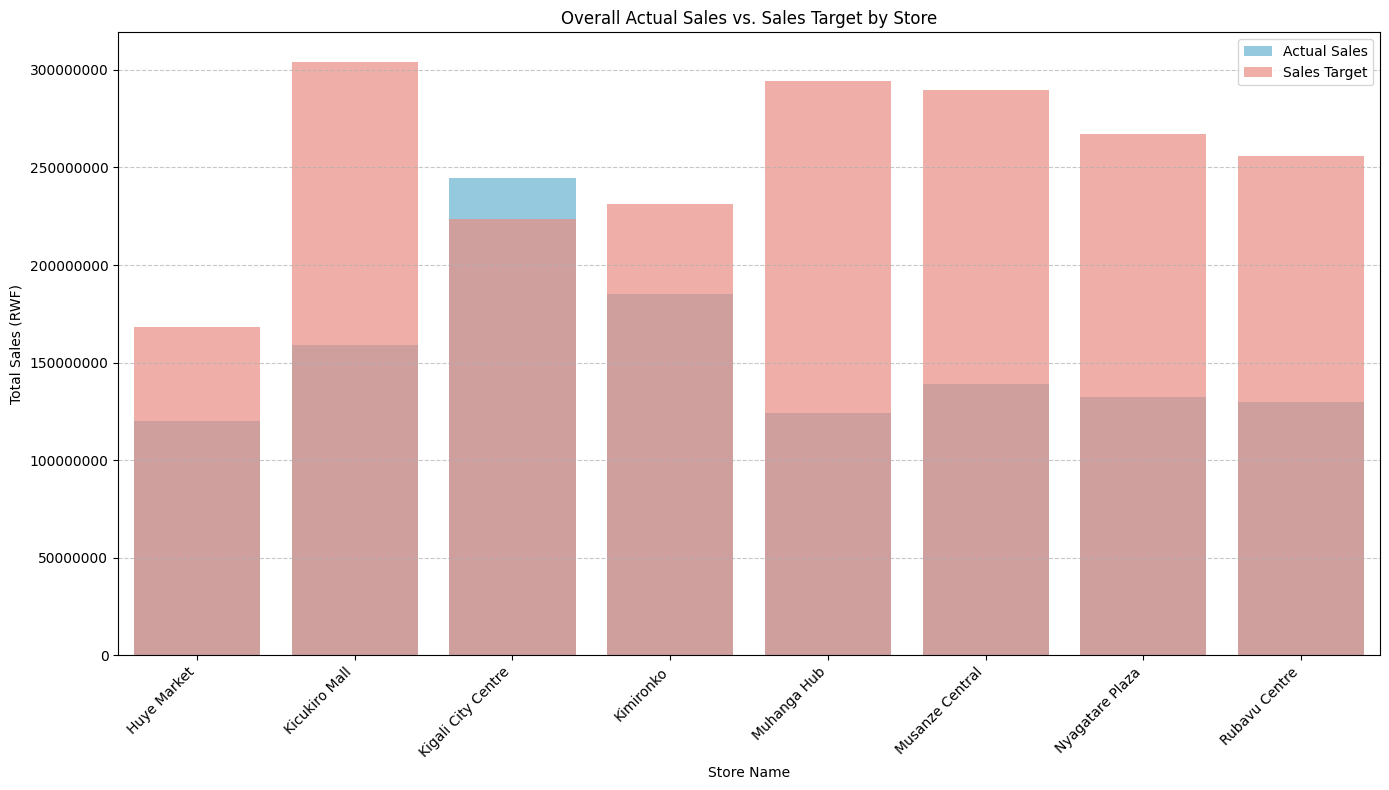

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.barplot(
    x='StoreName',
    y='TotalActualSales',
    data=store_overall_performance,
    color='skyblue', label='Actual Sales'
)
sns.barplot(
    x='StoreName',
    y='TotalSalesTarget',
    data=store_overall_performance,
    color='salmon', label='Sales Target', alpha=0.7
)

plt.title('Overall Actual Sales vs. Sales Target by Store')
plt.xlabel('Store Name')
plt.ylabel('Total Sales (RWF)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretations


Why Target Achievement Provides More Information than Raw Sales Figures
Target achievement provides critical insights that raw sales figures alone cannot offer, offering a more nuanced and actionable understanding of business performance:

Context and Performance Evaluation: Raw sales figures tell what happened (e.g., a store made X RWF in sales). Target achievement tells how well that performance aligns with expectations and strategic goals (e.g., did they meet, exceed, or fall short of X RWF?). This context is vital for evaluating management, store performance, and overall business health.

Motivation and Goal Setting: Targets act as clear objectives, motivating teams and individuals. Tracking achievement against these targets reinforces desired behaviors and helps in setting realistic yet challenging future goals. Without targets, sales figures can seem arbitrary, making it difficult to assess true success or failure.

Resource Allocation and Strategy Adjustment: When a store consistently misses targets, it signals a need for intervention – perhaps more marketing, different product assortment, improved staff training, or even a reassessment of the target itself. Conversely, consistently exceeding targets might indicate an opportunity to invest more in a successful store or to raise future targets. Raw sales alone don't provide this directional guidance.


Understanding Efficiency and Potential: A store with lower raw sales might still be highly efficient and effective if it consistently hits or exceeds its more modest targets, demonstrating strong performance relative to its resources or market. Conversely, a store with high raw sales that consistently misses very ambitious targets might be underperforming relative to its potential. Target achievement highlights this efficiency.

In essence, while raw sales figures are a measure of output, target achievement measures the effectiveness and efficiency of the efforts put into achieving that output. It transforms data into actionable intelligence, guiding strategic decisions and operational improvements.

Question 10: Employee Performance and Management Decision

What I Expect to Find

I expect that actual sales will not always be equal to the company's sales targets. Some store-month combinations may exceed their targets, while others may fall below them.

By comparing Actual Sales with Sales Targets and calculating the variance and achievement percentage, I expect to identify differences in target performance across stores and months. This analysis should provide a clearer view of performance than looking at sales figures alone because a store with high sales may still perform below its assigned target, while another store with lower sales may exceed its target.

The analysis will help identify store-month combinations that exceeded or failed to reach their targets and provide management with information about actual performance compared with planned performance.

In [ ]:
import pandas as pd

FILE = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(FILE, sheet_name="SalesRaw")
employees = pd.read_excel(FILE, sheet_name="DimEmployee")
products = pd.read_excel(FILE, sheet_name="DimProduct")

# Merge sales with employees and products for detailed analysis
employee_performance_df = sales.merge(
    employees[['EmployeeID', 'EmployeeName', 'Role', 'StoreID']],
    on='EmployeeID',
    how='left'
).merge(
    products[['ProductID', 'UnitCost']],
    on='ProductID',
    how='left'
)

# Calculate TotalCost and GrossProfit for each transaction
employee_performance_df['TotalCost'] = (
    employee_performance_df['Quantity']
    * employee_performance_df['UnitCost']
)
employee_performance_df['GrossProfit'] = (
    employee_performance_df['NetSales']
    - employee_performance_df['TotalCost']
)

print("Employee performance data prepared:")
display(employee_performance_df.head())

Employee performance data prepared:


,TransactionID,TransactionDate,StoreID_x,EmployeeID,CustomerID,ProductID,Quantity,UnitPrice,DiscountPct,SalesChannel,PaymentMethod,GrossSales,DiscountAmount,NetSales,EmployeeName,Role,StoreID_y,UnitCost,TotalCost,GrossProfit
0,TX100000,2025-06-29,3,2016,10538,10,2,2660.0,0.10,Store,Mobile Money,5320,532.0,4788.0,Employee 16,Sales Associate,3,1900,3800,988.0
1,TX100001,2025-12-31,6,2028,10107,26,6,25204.0,0.05,Store,Mobile Money,151224,7561.2,143662.8,Employee 28,Sales Associate,6,13500,81000,62662.8
2,TX100002,2025-08-30,2,2036,13854,51,1,8468.0,0.05,Online,Bank Transfer,8468,423.4,8044.6,Employee 36,Sales Associate,2,6100,6100,1944.6
3,TX100003,2025-06-09,5,2033,11230,3,3,1819.0,0.00,Store,Bank Transfer,5457,0.0,5457.0,Employee 33,Sales Associate,5,1300,3900,1557.0
4,TX100004,2025-01-10,3,2019,10395,42,1,2310.0,0.02,Store,Card,2310,46.2,2263.8,Employee 19,Sales Associate,3,1500,1500,763.8


In [ ]:
# Aggregate employee-level metrics
employee_summary = employee_performance_df.groupby(
    ['EmployeeID', 'EmployeeName', 'Role', 'StoreID_y']
).agg(
    NumberTransactions=('TransactionID', 'nunique'),
    TotalNetSales=('NetSales', 'sum'),
    TotalQuantitySold=('Quantity', 'sum'),
    TotalGrossProfit=('GrossProfit', 'sum')
).reset_index()

# Calculate derived metrics
employee_summary['AverageTransactionValue'] = (
    employee_summary['TotalNetSales']
    / employee_summary['NumberTransactions']
)
employee_summary['ProfitMargin'] = (
    (employee_summary['TotalGrossProfit'] / employee_summary['TotalNetSales']) * 100
)

# Sort by TotalNetSales for initial overview
employee_summary = employee_summary.sort_values(by='TotalNetSales', ascending=False)

print("Employee Performance Summary:")
display(employee_summary.round(2))

Employee Performance Summary:


,EmployeeID,EmployeeName,Role,StoreID_y,NumberTransactions,TotalNetSales,TotalQuantitySold,TotalGrossProfit,AverageTransactionValue,ProfitMargin
3,2004,Employee 04,Sales Associate,8,1278,64955495.93,3323,17754945.93,50825.90,27.33
25,2026,Employee 26,Store Supervisor,8,1273,59276859.30,3316,15699959.30,46564.70,26.49
27,2028,Employee 28,Sales Associate,6,863,43553312.72,2288,11443912.72,50467.34,26.28
21,2022,Employee 22,Sales Associate,1,729,42843510.39,1954,11727510.39,58770.25,27.37
7,2008,Employee 08,Sales Associate,1,769,40187279.00,2030,10939729.00,52259.14,27.22
24,2025,Employee 25,Sales Associate,6,848,38825748.40,2215,10344548.40,45785.08,26.64
31,2032,Employee 32,Sales Associate,5,628,38042561.46,1582,8777761.46,60577.33,23.07
5,2006,Employee 06,Sales Associate,6,832,37871278.80,2165,10017728.80,45518.36,26.45
13,2014,Employee 14,Sales Associate,1,711,36461738.95,1890,9717588.95,51282.33,26.65
2,2003,Employee 03,Sales Associate,1,662,35209959.12,1746,9066459.12,53187.25,25.75


Employee Performance by Role

In [ ]:
# Group by Role to compare performance within roles
role_summary = employee_summary.groupby('Role').agg(
    AvgNumberTransactions=('NumberTransactions', 'mean'),
    AvgTotalNetSales=('TotalNetSales', 'mean'),
    AvgTotalQuantitySold=('TotalQuantitySold', 'mean'),
    AvgAverageTransactionValue=('AverageTransactionValue', 'mean'),
    AvgTotalGrossProfit=('TotalGrossProfit', 'mean'),
    AvgProfitMargin=('ProfitMargin', 'mean'),
    NumEmployees=('EmployeeID', 'count')
).reset_index()

print("Performance Summary by Role:")
display(role_summary.round(2))

Performance Summary by Role:


,Role,AvgNumberTransactions,AvgTotalNetSales,AvgTotalQuantitySold,AvgAverageTransactionValue,AvgTotalGrossProfit,AvgProfitMargin,NumEmployees
0,Cashier,573.14,25353491.62,1480.86,44238.19,7181034.48,28.40,7
1,Sales Associate,631.35,32101727.99,1641.31,50851.49,8497152.99,26.49,26
2,Store Supervisor,653.29,31749807.69,1695.14,48988.52,8328300.55,26.19,7


Identifying Top Performers

In [ ]:
# 1. Employee with the highest sales
highest_sales_employee = employee_summary.sort_values(
    by='TotalNetSales', ascending=False
).iloc[0]
print("\nEmployee with the Highest Sales:")
display(highest_sales_employee.round(2))

# 2. Employee with the highest average transaction value
highest_avg_txn_value_employee = employee_summary.sort_values(
    by='AverageTransactionValue', ascending=False
).iloc[0]
print("\nEmployee with the Highest Average Transaction Value:")
display(highest_avg_txn_value_employee.round(2))

# 3. Employee with the highest gross profit
highest_gross_profit_employee = employee_summary.sort_values(
    by='TotalGrossProfit', ascending=False
).iloc[0]
print("\nEmployee with the Highest Gross Profit:")
display(highest_gross_profit_employee.round(2))


Employee with the Highest Sales:


,3
EmployeeID,2004
EmployeeName,Employee 04
Role,Sales Associate
StoreID_y,8
NumberTransactions,1278
TotalNetSales,64955495.93
TotalQuantitySold,3323
TotalGrossProfit,17754945.93
AverageTransactionValue,50825.896659
ProfitMargin,27.334016



Employee with the Highest Average Transaction Value:


,29
EmployeeID,2030
EmployeeName,Employee 30
Role,Sales Associate
StoreID_y,7
NumberTransactions,526
TotalNetSales,33965534.87
TotalQuantitySold,1429
TotalGrossProfit,8279734.87
AverageTransactionValue,64573.260209
ProfitMargin,24.376872



Employee with the Highest Gross Profit:


,3
EmployeeID,2004
EmployeeName,Employee 04
Role,Sales Associate
StoreID_y,8
NumberTransactions,1278
TotalNetSales,64955495.93
TotalQuantitySold,3323
TotalGrossProfit,17754945.93
AverageTransactionValue,50825.896659
ProfitMargin,27.334016


interpratation


Interpreting employee-level performance solely based on total sales figures can be misleading due to several factors. A true approach considering various metrics and contextual information is crucial for fair and effective management decisions.

Role Differences: Employees in different roles (e.g., Cashier, Sales Associate, Store Supervisor) have varying responsibilities and opportunities to generate sales. A Store Supervisor, for instance, might oversee overall store operations and strategic sales initiatives, while a Sales Associate directly interacts with customers to close sales. A Cashier's primary role might be processing transactions, not driving initial sales. Therefore, comparing total sales across different roles without adjusting for their responsibilities would be unfair and inaccurate.

Store Assignment and Location: The store where an employee works significantly impacts their sales potential. Stores in high-traffic urban areas or with a larger customer base (e.g., 'Kigali City Centre') naturally tend to have higher overall sales volumes compared to smaller stores or those in secondary cities (e.g., 'Muhanga Hub' or 'Rubavu Centre'). An employee in a lower-performing store might be excelling relative to their store's potential, even if their absolute sales figures are lower than an average performer in a high-volume store.


Conclusion: Management should look beyond just total sales. Metrics like Gross Profit, Profit Margin, Number of Transactions, and Average Transaction Value provide a more comprehensive view. More importantly, performance should be evaluated relative to the employee's role and store's context, not just absolute numbers. For instance, comparing a Cashier's average transaction value to a Sales Associate's might be more insightful than comparing their total sales.